# Notebook 03: **etiquetado gramatical, análisis sintáctico y entidades nombradas**

**Curso:** Procesamiento de Lenguaje Natural — Especialización en Inteligencia Artificial, Universidad de Cundinamarca
**Docente:** Paul Alexander Díaz Montaña
**Autor:** Yohan Nicolás Gómez Castañeda
**Base:** corpus CoNLL-2002 en español (Tjong Kim Sang, 2002) y modelo `es_core_news_md` de spaCy (Honnibal et al., 2020).

---

## Objetivo

Medir —no describir— el desempeño de un analizador lingüístico completo sobre noticias reales en español. La ventaja
de este corpus es que trae **anotación humana de referencia** en cada token: categoría gramatical con etiquetas
EAGLES y entidades nombradas en formato IOB. Eso permite pasar de «spaCy etiqueta bien» a una cifra con intervalo de
error, y —más importante— a una explicación de **en qué casos falla el modelo y en qué casos el desacuerdo no es un
error sino una diferencia de convención entre dos juegos de etiquetas**.

| Sección | Tema | Pregunta que responde |
|---|---|---|
| 1 | Estándar de oro | ¿Qué anota exactamente el corpus y con qué juego de etiquetas? |
| 2 | **Etiquetado gramatical (POS)** | ¿Cuánto acierta spaCy frente a la anotación humana? ¿Qué parte del desacuerdo es error y qué parte es el mapeo entre juegos de etiquetas? ¿Le gana una línea base sin contexto? |
| 3 | **Análisis sintáctico (parsing)** | ¿Qué estructura recupera el analizador de dependencias y qué se puede extraer de ella? ¿Cómo resuelve la ambigüedad de adjunción? |
| 4 | **Reconocimiento de entidades (NER)** | ¿Cuál es la precisión, la exhaustividad y la F1 por entidad completa? ¿Qué tipos de error dominan? |
| 5 | Hallazgos | — |

El notebook 01 dejó dos decisiones que aquí se respetan: el etiquetado y el reconocimiento de entidades se ejecutan
sobre el **texto original**, sin minúsculas ni eliminación de tildes, porque ambas operaciones destruyen la
información de la que dependen estas tareas.

## 0. Configuración del entorno

In [1]:
# Funciona igual en Google Colab y en local. En Colab clona el repositorio para disponer del paquete `pln_lab`
# y descarga el modelo de spaCy si hace falta.
import importlib.util, os, subprocess, sys
from pathlib import Path

# NLTK debe autorizar el proxy ANTES de cualquier descarga (inocuo en Colab).
os.environ.setdefault("NLTK_ALLOW_PROXIED_URLOPEN", "1")

REPO = "https://github.com/Nicolas2322/lab-procesamiento-texto.git"
EN_COLAB = "google.colab" in sys.modules

def raiz_del_repositorio() -> Path:
    for candidata in [Path.cwd(), *Path.cwd().parents]:
        if (candidata / "src" / "pln_lab").exists():
            return candidata
    if EN_COLAB:
        destino = Path("/content/lab-procesamiento-texto")
        if not destino.exists():
            subprocess.run(["git", "clone", "-q", REPO, str(destino)], check=True)
        return destino
    raise FileNotFoundError("Ejecute el notebook desde la carpeta del repositorio.")

RAIZ = raiz_del_repositorio()
sys.path.insert(0, str(RAIZ / "src"))

# El modelo mediano incluye etiquetador, analizador de dependencias y reconocedor de entidades.
if importlib.util.find_spec("es_core_news_md") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_md", "-q"], check=True)

print("Raíz del repositorio:", RAIZ, "| Colab:", EN_COLAB)

Raíz del repositorio: /home/claude/lab-procesamiento-texto | Colab: False


In [2]:
import json, random, time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from spacy import displacy
from spacy.tokens import Doc

from pln_lab.corpus import cargar_documentos_efe, documentos_a_dataframe
from pln_lab.etiquetado import (
    CATEGORIAS_UPOS, MAPA_EAGLES, TIPOS_ENTIDAD, EtiquetadorMasFrecuente, a_upos,
    clasificar_error, contar_entidades, prf, profundidad_arbol, profundidad_token, tramos_iob,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
sorteo = random.Random(SEED)  # generador propio: el muestreo no depende del resto del notebook

DIR_FIG = RAIZ / "notebooks" / "figuras"; DIR_RES = RAIZ / "notebooks" / "resultados"
for d in (DIR_FIG, DIR_RES):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
AZUL, ROJO, VERDE, GRIS, NARANJA, MORADO = "#2563eb", "#dc2626", "#16a34a", "#6b7280", "#d97706", "#7c3aed"
pd.set_option("display.max_colwidth", 90)

METRICAS = {}

def guardar_figura(nombre):
    plt.savefig(DIR_FIG / f"{nombre}.png"); plt.show()

def pct(x, d=1):
    return f"{100 * x:.{d}f} %"

print("spaCy", spacy.__version__, "| pandas", pd.__version__)

spaCy 3.8.16 | pandas 3.0.2


## 1. El corpus como estándar de oro

La parte en español de **CoNLL-2002** (Tjong Kim Sang, 2002) reúne noticias de la agencia EFE de mayo de 2000. Cada
token viene con tres campos: la **palabra**, su **categoría gramatical** en el juego EAGLES y su **etiqueta de
entidad** en formato IOB. El corpus se distribuye ya tokenizado, y eso es una ventaja metodológica: al alimentar a
spaCy con la misma segmentación del estándar de oro, las diferencias que se midan son diferencias de *etiquetado*, no
de *tokenización*. Si se dejara que spaCy retokenizara, cualquier discrepancia de segmentación (los enclíticos, las
contracciones *al* y *del*, las siglas con puntos) desalinearía las secuencias y contaminaría todas las métricas.

La evaluación se hace sobre una **muestra aleatoria de 3.000 oraciones**, suficiente para que las cifras sean
estables y barata en tiempo de cómputo. Se descartan las oraciones de menos de 3 tokens (líneas de separación,
titulares sueltos) y las de más de 80 (bloques de resultados deportivos que la anotación trata como una sola
oración).

In [3]:
documentos = cargar_documentos_efe()
oraciones_todas = [o for d in documentos for o in d.oraciones]
oraciones_utiles = [o for o in oraciones_todas if 3 <= len(o) <= 80]

indices = sorteo.sample(range(len(oraciones_utiles)), 3000)
conjunto_indices = set(indices)
muestra = [oraciones_utiles[i] for i in indices]
resto = [o for i, o in enumerate(oraciones_utiles) if i not in conjunto_indices]  # para la línea base

resumen = pd.Series({
    "Noticias": len(documentos),
    "Oraciones anotadas": len(oraciones_todas),
    "Oraciones utilizables (3–80 tokens)": len(oraciones_utiles),
    "Oraciones de la muestra de evaluación": len(muestra),
    "Tokens de la muestra": sum(len(o) for o in muestra),
    "Etiquetas EAGLES distintas": len({p for o in oraciones_todas for _, p, _ in o}),
}, name="valor")
METRICAS["corpus"] = {k: int(v) for k, v in resumen.items()}
display(resumen.to_frame())

# Distribución de las anotaciones de entidad en todo el corpus
iob = Counter(i for o in oraciones_todas for _, _, i in o)
print("Etiquetas IOB:", dict(iob.most_common()))
print("\nEjemplo de anotación (primeros 18 tokens de una oración):")
display(pd.DataFrame(muestra[7][:18], columns=["palabra", "EAGLES", "IOB"]).T)

,valor
Noticias,998
Oraciones anotadas,11755
Oraciones utilizables (3–80 tokens),10068
Oraciones de la muestra de evaluación,3000
Tokens de la muestra,107033
Etiquetas EAGLES distintas,60


Etiquetas IOB: {'O': 322631, 'B-ORG': 10490, 'I-ORG': 7462, 'B-LOC': 6981, 'B-PER': 6278, 'I-PER': 5396, 'I-MISC': 4423, 'B-MISC': 2957, 'I-LOC': 2553}

Ejemplo de anotación (primeros 18 tokens de una oración):


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
palabra,La,delegada,en,Cádiz,de,la,Consejería,de,Asuntos,Sociales,",",Prudencia,Rebollo,",",dijo,hoy,que,su
EAGLES,DA,NC,SP,NC,SP,DA,NC,SP,NC,AQ,Fc,VMM,NC,Fc,VMI,RG,CS,DP
IOB,O,O,O,B-LOC,O,O,B-ORG,I-ORG,I-ORG,I-ORG,O,B-PER,I-PER,O,O,O,O,O


In [4]:
# Se analiza la muestra con spaCy respetando la tokenización del corpus.
nlp = spacy.load("es_core_news_md")
print("Componentes:", nlp.pipe_names)

inicio = time.time()
docs_spacy = list(nlp.pipe(
    [Doc(nlp.vocab, words=[w for w, _, _ in o]) for o in muestra], batch_size=64))
duracion = time.time() - inicio
n_tokens_muestra = sum(len(o) for o in muestra)
METRICAS["rendimiento"] = {
    "segundos": round(duracion, 2),
    "tokens_por_segundo": round(n_tokens_muestra / duracion),
}
print(f"{n_tokens_muestra:,} tokens analizados en {duracion:.1f} s "
      f"({n_tokens_muestra / duracion:,.0f} tokens/s) con etiquetador, analizador y NER activos.")

Componentes: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


107,033 tokens analizados en 16.6 s (6,452 tokens/s) con etiquetador, analizador y NER activos.


**Análisis.** El corpus aporta tres niveles de anotación sobre el mismo texto, lo que permite evaluar las tres tareas
de este notebook con el mismo material y comparar sus dificultades. La anotación de entidades está muy desequilibrada
—la etiqueta `O` cubre la inmensa mayoría de los tokens— y esa es la razón por la que en la sección 4 no se reporta
exactitud por token sino precisión y exhaustividad por entidad completa: un sistema que no detectara ninguna entidad
alcanzaría una exactitud por token superior al 90 % y sería inútil.

El coste de cómputo no es un obstáculo: el modelo mediano procesa varios miles de tokens por segundo en dos CPU con
los tres componentes activos, de modo que la evaluación completa se resuelve en segundos y no hay que recortar la
muestra por razones de tiempo.

## 2. Etiquetado gramatical (*part-of-speech tagging*)

Etiquetar gramaticalmente es asignar a cada palabra su categoría en el contexto en que aparece. El problema no es
trivial porque en español la misma forma pertenece a categorías distintas según el contexto: *bajo* es preposición,
adjetivo, sustantivo o verbo; *la* es artículo o pronombre; *que* es conjunción o relativo. El etiquetado es,
además, el cimiento de todo lo que sigue: el analizador de dependencias y el lematizador de spaCy consumen la
categoría, y un error en ella se propaga.

### 2.1 Dos juegos de etiquetas y un mapeo

El corpus usa **EAGLES**, un juego posicional diseñado para las lenguas europeas: la primera letra da la categoría y
las siguientes el subtipo y los rasgos morfológicos. `VMIS3S0` es *verbo – main – indicativo – pasado simple – tercera
persona – singular*. CoNLL-2002 conserva los dos o tres primeros caracteres, lo que deja **60 etiquetas distintas**.

spaCy produce el juego **universal (UPOS)** de Universal Dependencies (Nivre et al., 2020): 17 categorías comunes a
todos los idiomas, pensadas para que un mismo análisis se pueda comparar entre lenguas.

Los dos juegos no son traducibles sin pérdida, y conviene enunciar las decisiones del mapeo antes de medir, porque de
ellas dependen las cifras:

| Grupo EAGLES | UPOS | Decisión y por qué |
|---|---|---|
| `NC` / `NP` | `NOUN` / `PROPN` | Directo. Es el grupo donde el corpus resultará ser menos fiable (§2.4). |
| `VM` | `VERB` | Verbo pleno. |
| `VA` (*haber*) / `VS` (*ser*) | `AUX` | UD reserva `AUX` para auxiliares y cópulas; EAGLES ya los separa por lema, así que el mapeo es mecánico. Introduce desacuerdos cuando *ser* es verbo predicativo y no cópula. |
| `AQ` / `AO` | `ADJ` | UD no distingue el ordinal del calificativo. |
| `RG` / `RN` | `ADV` | UPOS no tiene categoría para la negación: *no* y *nunca* son adverbios. |
| `SP` | `ADP` | Directo. |
| `DA` `DD` `DP` `DI` `DT` `DE` | `DET` | Artículos, demostrativos, posesivos, indefinidos, interrogativos y exclamativos. |
| `DN` | `NUM` | **Excepción deliberada:** EAGLES clasifica los cardinales como determinantes, UD los trata como `NUM` (*dos millones*). Mapearlos a `DET` generaría cientos de desacuerdos artificiales. |
| `PP` `PR` `PT` `P0` `PI` `PD` `PX` `PN` | `PRON` | Incluye el clítico `P0` (*se*), que UD también etiqueta `PRON`. |
| `CC` / `CS` | `CCONJ` / `SCONJ` | UD separa coordinantes y subordinantes; EAGLES también. |
| `Z` | `NUM` | Cifras. |
| `F*` | `PUNCT` | Cualquier etiqueta que empiece por `F` (`Fc`, `Fp`, `Fe`, `Fpa`…). |
| `I` | `INTJ` | Interjección. |
| `Y` | `PROPN` | Abreviaturas y siglas (`FC`, `SOS`); UD no tiene categoría propia y las trata como nombres. |

El mapeo se implementa en `pln_lab.etiquetado.a_upos`, que devuelve `None` para las etiquetas no cubiertas para poder
contarlas en lugar de esconderlas bajo una categoría por defecto.

In [5]:
# Cobertura del mapeo y tamaño de cada grupo en el corpus completo
cuentas_eagles = Counter(p for o in oraciones_todas for _, p, _ in o)
tabla_mapeo = pd.DataFrame([
    {"EAGLES": e, "tokens": n, "UPOS": a_upos(e)} for e, n in cuentas_eagles.most_common()
])
sin_mapear = tabla_mapeo[tabla_mapeo.UPOS.isna()]
print(f"Etiquetas EAGLES distintas: {len(tabla_mapeo)} | sin mapeo: {len(sin_mapear)} "
      f"({sin_mapear.tokens.sum() if len(sin_mapear) else 0} tokens)")

# Agregado por categoría universal, con las etiquetas EAGLES que la alimentan
agregado = (tabla_mapeo.dropna(subset=["UPOS"]).groupby("UPOS")
            .agg(tokens=("tokens", "sum"), etiquetas_eagles=("EAGLES", lambda s: ", ".join(sorted(s))))
            .sort_values("tokens", ascending=False))
agregado["% del corpus"] = (100 * agregado.tokens / agregado.tokens.sum()).round(1)
METRICAS["mapeo"] = {"etiquetas_eagles": len(tabla_mapeo), "sin_mapeo": len(sin_mapear),
                     "categorias_upos": len(agregado)}
display(agregado[["tokens", "% del corpus", "etiquetas_eagles"]])

Etiquetas EAGLES distintas: 60 | sin mapeo: 0 (0 tokens)


,tokens,% del corpus,etiquetas_eagles
UPOS,,,
NOUN,89469,24.2,NC
ADP,61145,16.6,SP
PUNCT,48374,13.1,"Faa, Fat, Fc, Fd, Fe, Fg, Fh, Fia, Fit, Fp, Fpa, Fpt, Fs, Ft, Fx, Fz"
DET,48264,13.1,"DA, DD, DE, DI, DP, DT"
VERB,32638,8.8,"VMG, VMI, VMM, VMN, VMP, VMS"
ADJ,32530,8.8,"AO, AQ"
PRON,13953,3.8,"P0, PD, PI, PN, PP, PR, PT, PX"
NUM,11166,3.0,"DN, Z"
ADV,8942,2.4,"RG, RN"


**Análisis.** El mapeo cubre las 60 etiquetas del corpus sin dejar ningún token fuera, y reduce un juego posicional de
60 símbolos a 14 categorías universales (de las 17 de UD no aparecen `SYM`, `PART` ni `X`, que el español apenas usa
y que este corpus no anota). La concentración es extrema: nombres, preposiciones, determinantes y adjetivos suman más
de la mitad de los tokens, y las categorías pequeñas (`INTJ`, `PROPN`) tienen tan pocos casos que su exactitud, medida
más abajo, no es estadísticamente informativa por sí sola.

Conviene notar dónde el mapeo es una **decisión** y no una traducción. Las dos que más pesan son `VA`/`VS` → `AUX`
(el corpus distingue *haber* y *ser* por lema, no por función, así que todo *ser* se vuelve auxiliar aunque en
*«la reunión fue en Madrid»* sea el verbo principal) y `DN` → `NUM` (los cardinales). La sección 2.4 cuantifica
cuánto del desacuerdo total es atribuible a estas decisiones.

### 2.2 Exactitud de spaCy frente a la anotación humana

Se compara token a token la categoría universal que predice spaCy con la que resulta de mapear la etiqueta EAGLES del
corpus. La métrica es la **exactitud** (proporción de tokens coincidentes), global y desagregada por categoría de
referencia.

In [6]:
# Alineación token a token: la tokenización es la misma, así que basta con recorrer en paralelo.
registros = []
for oracion, doc in zip(muestra, docs_spacy):
    for (palabra, eagles, entidad), token in zip(oracion, doc):
        registros.append((palabra, eagles, a_upos(eagles), token.pos_, token.tag_, entidad,
                          token.dep_, token.head.i, token.i))
comparacion = pd.DataFrame(registros, columns=[
    "palabra", "eagles", "oro", "spacy", "tag_spacy", "iob", "dep", "cabeza", "posicion"])
comparacion["acierto"] = comparacion.oro == comparacion.spacy

exactitud = comparacion.acierto.mean()
print(f"Tokens evaluados: {len(comparacion):,}")
print(f"Exactitud global: {pct(exactitud, 2)}")

por_categoria = (comparacion.groupby("oro")
                 .agg(tokens=("acierto", "size"), exactitud=("acierto", "mean"))
                 .sort_values("tokens", ascending=False))
por_categoria["exactitud"] = por_categoria.exactitud.round(3)
METRICAS["pos"] = {
    "tokens_evaluados": int(len(comparacion)),
    "exactitud_global": round(float(exactitud), 4),
    "exactitud_por_categoria": {k: round(float(v), 4) for k, v in
                                por_categoria.exactitud.items()},
    "tokens_por_categoria": {k: int(v) for k, v in por_categoria.tokens.items()},
}
display(por_categoria)

Tokens evaluados: 107,033
Exactitud global: 85.46 %


,tokens,exactitud
oro,,
NOUN,26100,0.685
ADP,17954,0.990
DET,14075,0.975
PUNCT,13848,0.997
VERB,9535,0.797
ADJ,9498,0.633
PRON,4150,0.852
NUM,2651,0.879
ADV,2571,0.944


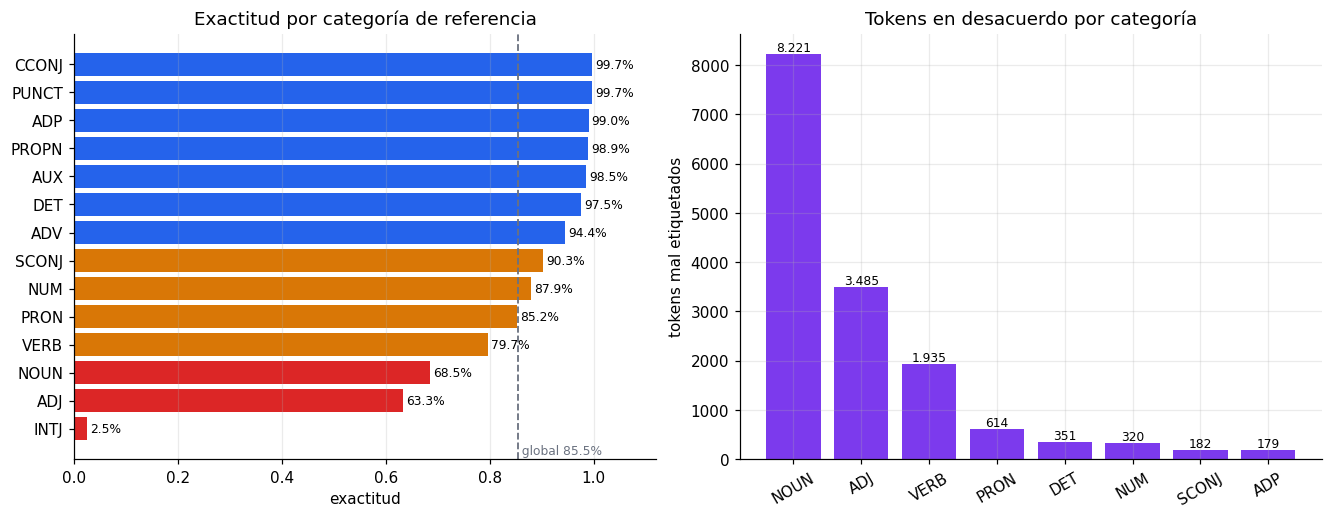

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6), layout="constrained")
orden = por_categoria.sort_values("exactitud")
colores = [ROJO if v < 0.75 else (NARANJA if v < 0.93 else AZUL) for v in orden.exactitud]
barras = ejes[0].barh(orden.index, orden.exactitud, color=colores)
ejes[0].bar_label(barras, labels=[f"{v:.1%}" for v in orden.exactitud], fontsize=8, padding=2)
ejes[0].axvline(exactitud, color=GRIS, ls="--", lw=1.2)
ejes[0].text(exactitud, -0.9, f" global {exactitud:.1%}", color=GRIS, fontsize=8)
ejes[0].set(title="Exactitud por categoría de referencia", xlabel="exactitud", xlim=(0, 1.12))
ejes[0].grid(axis="y", visible=False)

# El tamaño de cada categoría explica cuánto pesa su error en el total
peso_error = ((1 - por_categoria.exactitud) * por_categoria.tokens).sort_values(ascending=False)
barras2 = ejes[1].bar(peso_error.index[:8], peso_error.values[:8], color=MORADO)
ejes[1].bar_label(barras2, labels=[f"{int(v):,}".replace(",", ".") for v in peso_error.values[:8]], fontsize=8)
ejes[1].set(title="Tokens en desacuerdo por categoría", ylabel="tokens mal etiquetados")
ejes[1].tick_params(axis="x", rotation=30)
guardar_figura("fig03_01_pos_exactitud")

**Análisis.** La exactitud global queda muy por debajo del 95-97 % que reportan los modelos de spaCy para español en
evaluaciones estándar, y el desglose dice inmediatamente dónde está la pérdida: se concentra en `NOUN` y `ADJ`, las
dos categorías más numerosas, mientras que las categorías cerradas —preposiciones, determinantes, conjunciones,
puntuación— superan el 97 %. Ese patrón es la firma de un problema de **convención de anotación**, no de capacidad del
modelo: las categorías cerradas son listas finitas de palabras que cualquier etiquetador memoriza, y si el modelo
acierta casi siempre en ellas, no está fallando por debilidad general. El panel derecho lo confirma en términos de
volumen: casi todo el desacuerdo se acumula en nombres y adjetivos.

La categoría `INTJ` merece una nota aparte: su exactitud es prácticamente nula, pero mirando el corpus se ve por qué
—el corpus etiqueta como interjección tokens como *Jesús* (nombre de persona), *contra* o *bueno*—, y con apenas unas
decenas de casos no afecta al total. La matriz de confusión de la sección siguiente identifica el mecanismo exacto de
los desacuerdos grandes.

### 2.3 Matriz de confusión

La exactitud dice cuánto falla; la matriz de confusión dice **con qué lo confunde**. Se normaliza por fila (por
categoría de referencia) para que las categorías pequeñas sean legibles junto a las grandes.

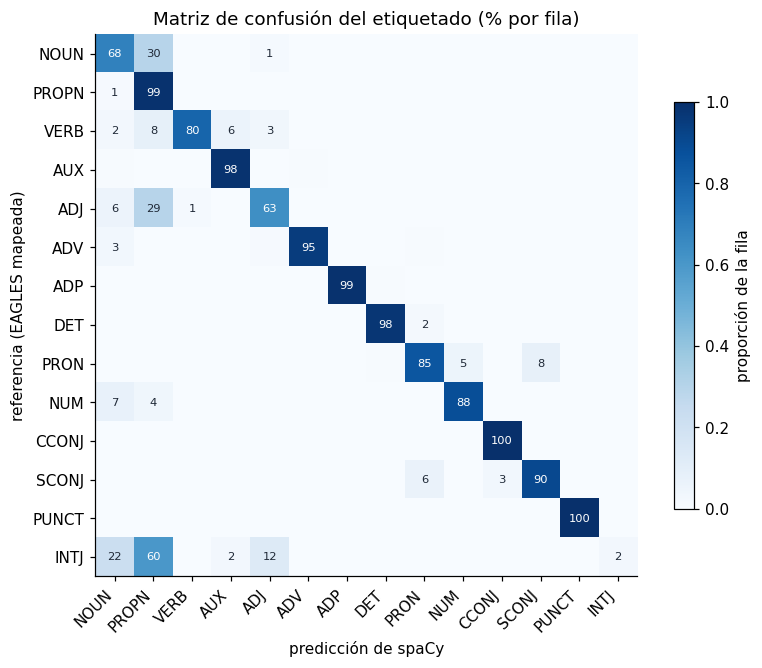

,oro,spacy,tokens,% del desacuerdo,ejemplos
0,NOUN,PROPN,7738,49.7,"EFE, Gobierno, Madrid, España"
1,ADJ,PROPN,2786,17.9,"San, Real, Nacional, José"
2,VERB,PROPN,801,5.1,"París, Sierra, Paulo, José"
3,VERB,AUX,579,3.7,"está, están, puede, podría"
4,ADJ,NOUN,545,3.5,"general, pleno, total, humanos"
5,PRON,SCONJ,327,2.1,que
6,DET,PRON,325,2.1,"lo, unos, una, otros"
7,NOUN,ADJ,318,2.0,"ex, pasado, próximo, pendiente"
8,VERB,ADJ,306,2.0,"aprobada, fallecidos, dicho, disputado"
9,VERB,NOUN,231,1.5,"partir, pesar, Respecto, conocer"


In [8]:
presentes = [c for c in CATEGORIAS_UPOS if c in set(comparacion.oro) | set(comparacion.spacy)]
matriz = pd.crosstab(comparacion.oro, comparacion.spacy).reindex(
    index=presentes, columns=presentes, fill_value=0)
matriz_pct = matriz.div(matriz.sum(axis=1).replace(0, 1), axis=0)

fig, eje = plt.subplots(figsize=(8.6, 6.4))
imagen = eje.imshow(matriz_pct.values, cmap="Blues", vmin=0, vmax=1)
eje.set_xticks(range(len(presentes)), presentes, rotation=45, ha="right")
eje.set_yticks(range(len(presentes)), presentes)
eje.set(xlabel="predicción de spaCy", ylabel="referencia (EAGLES mapeada)",
        title="Matriz de confusión del etiquetado (% por fila)")
for i in range(len(presentes)):
    for j in range(len(presentes)):
        v = matriz_pct.values[i, j]
        if v >= 0.01:
            eje.text(j, i, f"{100 * v:.0f}", ha="center", va="center", fontsize=7.5,
                     color="white" if v > 0.55 else "#1f2937")
eje.grid(False)
fig.colorbar(imagen, ax=eje, shrink=0.75, label="proporción de la fila")
guardar_figura("fig03_02_pos_confusion")

confusiones = (comparacion[~comparacion.acierto].groupby(["oro", "spacy"]).size()
               .sort_values(ascending=False).head(12).rename("tokens").reset_index())
confusiones["% del desacuerdo"] = (100 * confusiones.tokens / (~comparacion.acierto).sum()).round(1)
confusiones["ejemplos"] = [
    ", ".join(w for w, _ in Counter(
        comparacion[(comparacion.oro == o) & (comparacion.spacy == s)].palabra).most_common(4))
    for o, s in zip(confusiones.oro, confusiones.spacy)]
METRICAS["pos"]["confusiones"] = [
    {"oro": r.oro, "spacy": r.spacy, "tokens": int(r.tokens)} for r in confusiones.itertuples()]
display(confusiones)

**Análisis.** La matriz muestra una asimetría muy marcada: la confusión no está repartida, sino dominada por una
sola celda, **`NOUN` de referencia frente a `PROPN` de spaCy**, seguida de **`ADJ` frente a `PROPN`**. Los ejemplos
resuelven el enigma: son *Gobierno*, *Madrid*, *Ayuntamiento*, *Real*, *General*, *Nacional*… es decir, **nombres
propios**. spaCy los etiqueta como nombre propio; el corpus los etiqueta como nombre común o como adjetivo.

La explicación está en cómo se construyó CoNLL-2002: la anotación de entidades se hizo a mano, pero la capa
morfosintáctica se generó **automáticamente** con un etiquetador de la época y no se corrigió, porque la tarea
compartida evaluaba entidades, no categorías. El etiquetador de entonces analizaba *Madrid* como el nombre común
*madrid* y *Real Madrid* como adjetivo más nombre. En el corpus completo solo hay 1.846 tokens con la etiqueta `NP`
frente a más de 27.000 tokens con `NC` y mayúscula inicial: el propio estándar de oro es inconsistente en esta
distinción.

El resto de las confusiones sí son lingüísticamente interesantes y de tamaño mucho menor: `PRON`↔`SCONJ` (el *que*
relativo frente al *que* conjuntivo, una ambigüedad genuina del español), `DET`↔`PRON` (*la*, *los*, *una* usados sin
nombre detrás), `ADJ`↔`NOUN` (la conversión adjetivo-sustantivo: *los socialistas*, *el acusado*) y `VERB`→`AUX`
(perífrasis). La siguiente sección separa cuantitativamente estas dos poblaciones.

### 2.4 Cuánto del desacuerdo es error y cuánto es el mapeo

Tres hipótesis explicarían buena parte del desacuerdo sin que spaCy esté equivocado:

1. **Nombres propios.** Si el corpus etiqueta los nombres propios como `NC`/`AQ`, el desacuerdo debería concentrarse
   en los tokens que el propio corpus marca como parte de una entidad nombrada (esa capa **sí** está anotada a mano).
2. **`AUX` frente a `VERB`.** El mapeo convierte todo *ser* y todo *haber* en auxiliar, aunque a veces sean el verbo
   principal; y spaCy, al revés, marca como auxiliares verbos plenos en perífrasis (*va a presentar*, *tiene que
   hacer*).
3. **Determinantes y pronombres.** UD y EAGLES trazan la frontera en sitios distintos cuando la palabra aparece sin
   nombre detrás.

Cada hipótesis se comprueba relajando la comparación y midiendo cuánto sube la exactitud.

In [9]:
dentro_entidad = comparacion.iob != "O"
relajaciones = {
    "estricta": pd.Series(True, index=comparacion.index) & False,
    "NOUN≡PROPN": comparacion.oro.isin(["NOUN", "PROPN"]) & comparacion.spacy.isin(["NOUN", "PROPN"]),
    "VERB≡AUX": comparacion.oro.isin(["VERB", "AUX"]) & comparacion.spacy.isin(["VERB", "AUX"]),
    "DET≡PRON": comparacion.oro.isin(["DET", "PRON"]) & comparacion.spacy.isin(["DET", "PRON"]),
    "ADJ≡NOUN": comparacion.oro.isin(["ADJ", "NOUN"]) & comparacion.spacy.isin(["ADJ", "NOUN"]),
}
filas = []
acumulado = comparacion.acierto.copy()
for nombre, indulto in relajaciones.items():
    individual = (comparacion.acierto | indulto).mean()
    acumulado = acumulado | indulto
    filas.append({"criterio": nombre, "exactitud aislada": round(individual, 4),
                  "exactitud acumulada": round(acumulado.mean(), 4)})
tabla_relaj = pd.DataFrame(filas).set_index("criterio")

# Exactitud fuera y dentro de las entidades nombradas (capa anotada a mano)
exactitud_fuera = comparacion.loc[~dentro_entidad, "acierto"].mean()
exactitud_dentro = comparacion.loc[dentro_entidad, "acierto"].mean()
METRICAS["pos"]["relajaciones"] = tabla_relaj["exactitud aislada"].to_dict()
METRICAS["pos"]["exactitud_acumulada"] = tabla_relaj["exactitud acumulada"].to_dict()
METRICAS["pos"].update({
    "exactitud_fuera_entidades": round(float(exactitud_fuera), 4),
    "exactitud_dentro_entidades": round(float(exactitud_dentro), 4),
    "tokens_en_entidades": int(dentro_entidad.sum()),
    "desacuerdos_en_entidades": int((~comparacion.acierto & dentro_entidad).sum()),
    "desacuerdos_totales": int((~comparacion.acierto).sum()),
})
print(f"Exactitud fuera de entidades: {pct(exactitud_fuera, 2)} "
      f"({(~dentro_entidad).sum():,} tokens)")
print(f"Exactitud dentro de entidades: {pct(exactitud_dentro, 2)} "
      f"({dentro_entidad.sum():,} tokens)")
print(f"Desacuerdos que caen dentro de una entidad: "
      f"{pct((~comparacion.acierto & dentro_entidad).sum() / (~comparacion.acierto).sum(), 1)} del total")
display(tabla_relaj)

Exactitud fuera de entidades: 95.19 % (93,455 tokens)
Exactitud dentro de entidades: 18.52 % (13,578 tokens)
Desacuerdos que caen dentro de una entidad: 71.1 % del total


,exactitud aislada,exactitud acumulada
criterio,,
estricta,0.8546,0.8546
NOUN≡PROPN,0.9270,0.9270
VERB≡AUX,0.8600,0.9324
DET≡PRON,0.8579,0.9357
ADJ≡NOUN,0.8627,0.9438


In [10]:
# Casos concretos de las hipótesis 2 y 3
def contingencia(filtro, titulo):
    sub = comparacion[filtro]
    t = pd.crosstab(sub.eagles, sub.spacy)
    print(f"\n{titulo}  (n = {len(sub):,})")
    display(t)
    return t

# ser / estar / haber: el corpus los marca por lema (VS, VA); spaCy decide por función
contingencia(comparacion.eagles.str.startswith(("VS", "VA")),
             "Verbos que EAGLES trata como auxiliares (VS = ser, VA = haber)")
# participios: VMP puede funcionar como verbo (compuesto/pasiva) o como adjetivo
contingencia(comparacion.eagles == "VMP", "Participios de verbo pleno (VMP)")
# El desacuerdo grande va en la dirección contraria: verbos que EAGLES trata como plenos (VM) y
# spaCy como auxiliares. ¿Qué verbos son?
verbo_a_aux = comparacion[(comparacion.oro == "VERB") & (comparacion.spacy == "AUX")]
formas_aux = verbo_a_aux.palabra.str.lower().value_counts()
print(f"\nTokens que EAGLES etiqueta VM (verbo pleno) y spaCy AUX: {len(verbo_a_aux):,}")
print("  formas más frecuentes:", ", ".join(f"{w} ({n})" for w, n in formas_aux.head(8).items()))
METRICAS["pos"]["verbo_a_aux"] = {"tokens": int(len(verbo_a_aux)),
                                  "formas": {w: int(n) for w, n in formas_aux.head(8).items()}}

ejemplos_part = comparacion[(comparacion.eagles == "VMP") & (comparacion.spacy == "ADJ")]
print("Participios que spaCy analiza como adjetivo:",
      ", ".join(ejemplos_part.palabra.str.lower().value_counts().head(8).index))


Verbos que EAGLES trata como auxiliares (VS = ser, VA = haber)  (n = 1,681)


spacy,ADV,AUX,NOUN,PROPN,VERB
eagles,,,,,
VAI,0,680,0,0,0
VAM,0,1,0,0,0
VAN,0,40,1,0,0
VAP,0,4,0,0,0
VAS,0,42,0,3,0
VSG,0,10,0,0,0
VSI,0,673,10,2,0
VSM,0,2,0,0,0
VSN,0,85,0,0,1



Participios de verbo pleno (VMP)  (n = 1,009)


spacy,ADJ,AUX,NOUN,PROPN,VERB
eagles,,,,,
VMP,238,16,37,13,705



Tokens que EAGLES etiqueta VM (verbo pleno) y spaCy AUX: 579
  formas más frecuentes: está (97), están (46), puede (39), podría (30), debe (29), pueden (22), estará (20), debería (17)
Participios que spaCy analiza como adjetivo: aprobada, fallecidos, visto, dicho, disputado, automatizado, acusado, fallecido


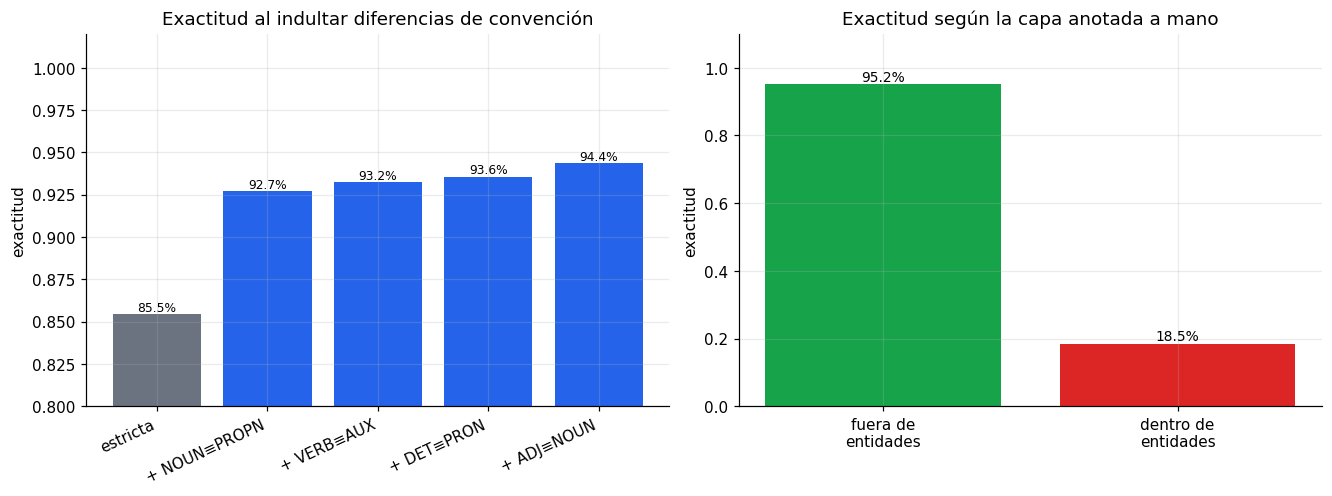

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.4), layout="constrained")
valores = [exactitud] + list(tabla_relaj["exactitud acumulada"].values[1:])
etiquetas = ["estricta"] + [f"+ {c}" for c in tabla_relaj.index[1:]]
barras = ejes[0].bar(range(len(valores)), valores, color=[GRIS] + [AZUL] * (len(valores) - 1))
ejes[0].bar_label(barras, labels=[f"{v:.1%}" for v in valores], fontsize=8)
ejes[0].set_xticks(range(len(valores)), etiquetas, rotation=25, ha="right")
ejes[0].set(title="Exactitud al indultar diferencias de convención", ylabel="exactitud",
            ylim=(0.8, 1.02))

barras2 = ejes[1].bar(["fuera de\nentidades", "dentro de\nentidades"],
                      [exactitud_fuera, exactitud_dentro], color=[VERDE, ROJO])
ejes[1].bar_label(barras2, labels=[f"{v:.1%}" for v in (exactitud_fuera, exactitud_dentro)], fontsize=9)
ejes[1].set(title="Exactitud según la capa anotada a mano", ylabel="exactitud", ylim=(0, 1.1))
guardar_figura("fig03_03_pos_desacuerdos")

**Análisis.** La hipótesis 1 se confirma de forma contundente. La exactitud sobre los 93.455 tokens que **no** forman
parte de ninguna entidad es del 95,2 %, mientras que dentro de las entidades se hunde al 18,5 %. Dicho de otro modo:
el 71 % de todos los desacuerdos del corpus (11.063 de 15.561) cae sobre el 13 % de los tokens que el corpus marca
como parte de una entidad nombrada. Indultar la distinción `NOUN`/`PROPN` sube la exactitud del 85,5 % al 92,7 % por
sí sola. **Conclusión metodológica: la exactitud estricta del 85,5 % subestima gravemente a spaCy; la cifra
defendible para este modelo, medida donde el estándar de oro es consistente, es el 95,2 % de los tokens fuera de
entidades.** Aplicando las cuatro relajaciones a la vez se llega al 94,4 %, valor muy próximo al anterior por otra vía.

Las hipótesis 2 y 3 aportan mucho menos —entre 0,5 y 1,7 puntos cada una— pero son las lingüísticamente
informativas, y el detalle es el contrario del que cabría esperar:

* **`VS` (*ser*) y `VA` (*haber*) → `AUX` funciona casi perfectamente** (98,5 % de exactitud): de los 1.681 tokens
  que EAGLES marca como auxiliares, spaCy coincide en todos salvo unas decenas. El mapeo no es el problema aquí.
* **El desacuerdo grande va en la dirección opuesta**: 579 tokens que EAGLES considera verbos plenos (`VM`) y spaCy
  etiqueta `AUX`. Las formas lo explican: *está*, *están*, *puede*, *debe*, *podría*, es decir los lemas **estar**
  (239 tokens), **poder** (203) y **deber** (90). EAGLES solo admite como auxiliares *haber* y *ser*; UD, en cambio,
  marca `AUX` la cópula *estar* y los modales en perífrasis (*puede presentar*, *debe aprobar*). Es una diferencia de
  inventario entre los dos esquemas, no un error de análisis.
* **Participios `VMP`.** De los 1.009 participios de verbo pleno, spaCy asigna `VERB` a 705 (tiempos compuestos y
  pasivas: *ha presentado*, *fue detenido*) y `ADJ` a 238 (*aprobada*, *fallecidos*, *acusado*, *disputado*). UD
  contempla las dos lecturas según la función y el reparto de spaCy es defendible caso por caso; el corpus decide por
  morfología y siempre dice verbo.
* **`DET`/`PRON`.** Frontera convencional en *«los que llegaron»*, *«una de las víctimas»*: UD etiqueta `PRON` cuando
  no hay nombre, EAGLES conserva el determinante. Unos 325 tokens.

Queda un residuo genuino de error, sobre todo el `que` relativo frente al conjuntivo (327 tokens) y la conversión
adjetivo-sustantivo (545 tokens: *los socialistas*, *el acusado*), que son ambigüedades reales del español y donde un
modelo estadístico acierta la mayoría de las veces pero no todas.

### 2.5 Línea base: la etiqueta más frecuente por palabra

Antes de celebrar cualquier cifra hay que compararla con lo que consigue el método más simple posible: asignar a cada
palabra **la categoría con la que aparece más veces** en un corpus de entrenamiento, sin mirar el contexto (Jurafsky y
Martin, 2025, cap. 8). Se entrena con las oraciones del corpus que **no** están en la muestra de evaluación
(7.000 aproximadamente) y se evalúa sobre la misma muestra, lo que hace la comparación directa.

La línea base tiene una propiedad que la hace especialmente reveladora aquí: al aprender del propio corpus,
**hereda también sus convenciones de anotación**, incluida la inconsistencia de los nombres propios.

In [12]:
oraciones_entrenamiento = [[(w, a_upos(p)) for w, p, _ in o if a_upos(p)] for o in resto]
base = EtiquetadorMasFrecuente().entrenar(oraciones_entrenamiento)
print(f"Vocabulario memorizado: {len(base.tabla):,} formas | "
      f"categoría de respaldo para palabras nuevas: {base.respaldo}")

comparacion["base"] = [base.etiquetar(w) for w in comparacion.palabra]
comparacion["conocida"] = [base.conoce(w) for w in comparacion.palabra]
comparacion["acierto_base"] = comparacion.base == comparacion.oro

conocidas = comparacion[comparacion.conocida]
desconocidas = comparacion[~comparacion.conocida]
resumen_base = pd.DataFrame({
    "tokens": [len(comparacion), len(conocidas), len(desconocidas)],
    "% de la muestra": [1.0, len(conocidas) / len(comparacion), len(desconocidas) / len(comparacion)],
    "línea base": [comparacion.acierto_base.mean(), conocidas.acierto_base.mean(),
                   desconocidas.acierto_base.mean()],
    "spaCy": [comparacion.acierto.mean(), conocidas.acierto.mean(), desconocidas.acierto.mean()],
}, index=["todas", "palabras conocidas", "palabras desconocidas"])
METRICAS["pos"]["linea_base"] = {
    "vocabulario": len(base.tabla),
    "exactitud": round(float(comparacion.acierto_base.mean()), 4),
    "cobertura": round(float(comparacion.conocida.mean()), 4),
    "exactitud_conocidas": round(float(conocidas.acierto_base.mean()), 4),
    "exactitud_desconocidas": round(float(desconocidas.acierto_base.mean()), 4),
    "spacy_desconocidas": round(float(desconocidas.acierto.mean()), 4),
}
display(resumen_base.style.format({"% de la muestra": "{:.1%}", "línea base": "{:.1%}", "spaCy": "{:.1%}"}))

# Dos criterios que neutralizan la convención del corpus sobre los nombres propios
indulto_np = (comparacion.oro.isin(["NOUN", "PROPN"]) & comparacion.spacy.isin(["NOUN", "PROPN"]))
indulto_np_base = (comparacion.oro.isin(["NOUN", "PROPN"]) & comparacion.base.isin(["NOUN", "PROPN"]))
fuera = comparacion[~dentro_entidad]
criterios = pd.DataFrame({
    "línea base": [comparacion.acierto_base.mean(), (comparacion.acierto_base | indulto_np_base).mean(),
                   fuera.acierto_base.mean()],
    "spaCy": [comparacion.acierto.mean(), (comparacion.acierto | indulto_np).mean(), fuera.acierto.mean()],
}, index=["estricto (todo el corpus)", "NOUN≡PROPN indultado", "solo fuera de entidades"])
criterios["ventaja de spaCy"] = criterios.spaCy - criterios["línea base"]
METRICAS["pos"]["linea_base"]["exactitud_indultada"] = round(
    float((comparacion.acierto_base | indulto_np_base).mean()), 4)
METRICAS["pos"]["linea_base"]["exactitud_fuera_entidades"] = round(float(fuera.acierto_base.mean()), 4)
METRICAS["pos"]["spacy_indultada"] = round(float((comparacion.acierto | indulto_np).mean()), 4)
display(criterios.style.format("{:.4f}"))

# Las palabras desconocidas son en su mayoría nombres propios: se mide también con el indulto
indulto_desc = desconocidas.oro.isin(["NOUN", "PROPN"]) & desconocidas.spacy.isin(["NOUN", "PROPN"])
indulto_desc_base = desconocidas.oro.isin(["NOUN", "PROPN"]) & desconocidas.base.isin(["NOUN", "PROPN"])
METRICAS["pos"]["linea_base"]["desconocidas_en_entidades"] = round(
    float((desconocidas.iob != "O").mean()), 4)
METRICAS["pos"]["linea_base"]["desconocidas_indultado_spacy"] = round(
    float((desconocidas.acierto | indulto_desc).mean()), 4)
print(f"\nPalabras desconocidas: {(desconocidas.iob != 'O').mean():.1%} están dentro de una entidad nombrada.")
print(f"  con NOUN≡PROPN indultado — spaCy: {pct((desconocidas.acierto | indulto_desc).mean(), 1)} | "
      f"línea base: {pct((desconocidas.acierto_base | indulto_desc_base).mean(), 1)}")

Vocabulario memorizado: 22,839 formas | categoría de respaldo para palabras nuevas: NOUN


,tokens,% de la muestra,línea base,spaCy
todas,107033,100.0%,92.4%,85.5%
palabras conocidas,102231,95.5%,95.2%,86.4%
palabras desconocidas,4802,4.5%,32.3%,65.6%


,línea base,spaCy,ventaja de spaCy
estricto (todo el corpus),0.9239,0.8546,-0.0693
NOUN≡PROPN indultado,0.9285,0.9270,-0.0016
solo fuera de entidades,0.9398,0.9519,0.0121



Palabras desconocidas: 27.8% están dentro de una entidad nombrada.
  con NOUN≡PROPN indultado — spaCy: 79.2 % | línea base: 34.2 %


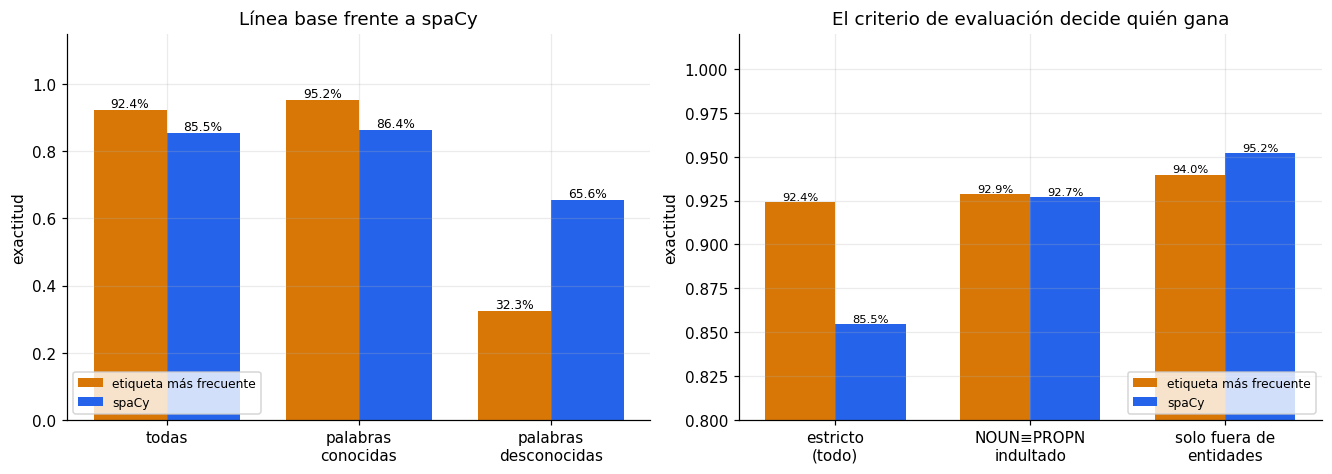

In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
x = np.arange(3); ancho = 0.38
b1 = ejes[0].bar(x - ancho / 2, resumen_base["línea base"], ancho, color=NARANJA, label="etiqueta más frecuente")
b2 = ejes[0].bar(x + ancho / 2, resumen_base["spaCy"], ancho, color=AZUL, label="spaCy")
for b in (b1, b2):
    ejes[0].bar_label(b, labels=[f"{v.get_height():.1%}" for v in b], fontsize=8)
ejes[0].set_xticks(x, ["todas", "palabras\nconocidas", "palabras\ndesconocidas"])
ejes[0].set(title="Línea base frente a spaCy", ylabel="exactitud", ylim=(0, 1.15))
ejes[0].legend(fontsize=8, loc="lower left")

x2 = np.arange(len(criterios)); ancho2 = 0.36
b1 = ejes[1].bar(x2 - ancho2 / 2, criterios["línea base"], ancho2, color=NARANJA, label="etiqueta más frecuente")
b2 = ejes[1].bar(x2 + ancho2 / 2, criterios["spaCy"], ancho2, color=AZUL, label="spaCy")
for b in (b1, b2):
    ejes[1].bar_label(b, labels=[f"{v.get_height():.1%}" for v in b], fontsize=7.5)
ejes[1].set_xticks(x2, ["estricto\n(todo)", "NOUN≡PROPN\nindultado", "solo fuera de\nentidades"])
ejes[1].set(title="El criterio de evaluación decide quién gana", ylabel="exactitud", ylim=(0.8, 1.02))
ejes[1].legend(fontsize=8, loc="lower right")
guardar_figura("fig03_04_pos_linea_base")

**Análisis.** El resultado es el más instructivo del notebook: **con el criterio estricto la línea base sin contexto
gana a spaCy por casi siete puntos** (92,4 % frente a 85,5 %). Sería absurdo concluir que memorizar la etiqueta más
frecuente etiqueta mejor el español que un modelo neuronal. Lo que ocurre es que la línea base se entrenó con el mismo
corpus y aprendió también su convención: en él *Madrid* es `NOUN` y *Real* es `ADJ`. La línea base no mide calidad
lingüística, mide **acuerdo con la convención del corpus**, y por construcción parte con ventaja en esa medida.

Al cambiar el criterio, la ventaja se disuelve. Indultando `NOUN`/`PROPN` los dos sistemas quedan empatados en torno
al 92,8 %, y **restringiendo la evaluación a los tokens fuera de entidades —la zona donde la anotación es
consistente— spaCy pasa por delante** (95,2 % frente a 94,0 %). Una ventaja de poco más de un punto sobre un método
que solo memoriza puede parecer decepcionante, y conviene decir por qué no lo es: el 95,5 % de los tokens de la
muestra son palabras que la línea base ya vio, y en el español periodístico la mayoría de las palabras tienen una
categoría dominante abrumadora. La exactitud global está saturada por esos casos fáciles.

La diferencia real aparece donde importa: en las **palabras desconocidas**. Son el 4,5 % de la muestra, y ahí la línea
base se derrumba al 32,3 % porque no tiene más recurso que la categoría mayoritaria (`NOUN`), mientras que spaCy
alcanza el 65,6 % usando el contexto y la forma de la palabra (sufijos, mayúsculas, vectores). Y esa cifra de spaCy
sigue penalizada por el mismo artefacto de antes: el 27,8 % de las palabras desconocidas está dentro de una entidad
nombrada —lo esperable, son nombres propios—, de modo que al indultar `NOUN`/`PROPN` spaCy sube al 79,2 % y la línea
base apenas se mueve. Las palabras nunca vistas son justamente la población que domina al llevar un sistema a un
dominio nuevo, y ahí la línea base no es una alternativa: duplica su tasa de error.

Conclusión práctica: **una línea base es imprescindible, pero una línea base que gana debe hacer sospechar del
criterio de evaluación antes que del sistema evaluado.** Y la exactitud global, cuando el 95 % de los casos son
triviales, es una métrica poco informativa: conviene mirar siempre el subconjunto difícil por separado.

## 3. Análisis sintáctico (*parsing*)

### 3.1 Dependencias frente a constituyentes

Hay dos formas clásicas de representar la estructura de una oración:

* El **análisis de constituyentes** (gramáticas de estructura de frase) agrupa palabras en sintagmas anidados: una
  oración se descompone en sintagma nominal y sintagma verbal, el sintagma verbal en verbo y sintagma nominal, y así
  sucesivamente. Los nodos internos son categorías abstractas (SN, SV, SP) que no corresponden a ninguna palabra.
* El **análisis de dependencias** prescinde de los nodos abstractos: cada palabra se enlaza directamente con la
  palabra de la que depende (su *cabeza*) mediante una relación etiquetada (`nsubj`, `obj`, `det`, `case`…). El
  resultado es un árbol con tantos nodos como palabras y una única raíz, normalmente el verbo principal.

Para el español y para el procesamiento aplicado las dependencias tienen tres ventajas decisivas: el orden de
palabras es libre —sujeto posverbal, complementos desplazados— y las dependencias lo absorben sin multiplicar reglas;
las relaciones son directamente los papeles que interesan a la extracción de información (quién hace qué a quién); y
Universal Dependencies (Nivre et al., 2020) ofrece un inventario común a más de cien idiomas, lo que permite entrenar
y comparar entre lenguas. spaCy implementa exclusivamente análisis de dependencias, con el esquema UD.

In [14]:
# Tres oraciones reales del corpus con estructuras distintas: aposición, cadena de sintagmas
# preposicionales y oración de relativo con coordinación. Se localizan por su comienzo para que
# la selección sea reproducible; si alguna no estuviera en la muestra se toma una equivalente.
def texto_de(oracion):
    return " ".join(w for w, _, _ in oracion)

INICIOS = ["El consejero de Cultura", "El jefe del Ejecutivo autonómico", "El Real Madrid controla"]

def es_prosa(oracion):
    """Descarta cabeceras de agencia y bloques de resultados deportivos."""
    palabras = [w for w, _, _ in oracion]
    return (10 <= len(oracion) <= 22
            and not any(w.startswith("EFE") for w in palabras)
            and any(p.startswith("VM") for _, p, _ in oracion)
            and not any(p in ("Fz", "Fh") for _, p, _ in oracion))

reserva = [o for o in muestra if es_prosa(o)]
ejemplos = []
for inicio in INICIOS:
    hallada = next((o for o in muestra if texto_de(o).startswith(inicio)), None)
    ejemplos.append(hallada if hallada is not None else reserva[len(ejemplos)])
docs_ejemplo = [nlp(Doc(nlp.vocab, words=[w for w, _, _ in o])) for o in ejemplos]

def tabla_dependencias(doc):
    """Representación textual del árbol: token, cabeza, relación y profundidad."""
    return pd.DataFrame({
        "token": [t.text for t in doc],
        "UPOS": [t.pos_ for t in doc],
        "relación": [t.dep_ for t in doc],
        "cabeza": [t.text if t.head == t else t.head.text for t in doc],
        "profundidad": [profundidad_token(t) for t in doc],
        "hijos": [" ".join(c.text for c in t.children) or "—" for t in doc],
    })

for doc in docs_ejemplo:
    print("»", doc.text)
    try:
        displacy.render(doc, style="dep", jupyter=True,
                        options={"compact": True, "distance": 105, "font": "Arial", "bg": "#ffffff"})
    except Exception as error:  # en algunos entornos displacy no puede dibujar
        print("  (displacy no disponible:", error, ")")
    display(tabla_dependencias(doc))

» El consejero de Cultura , Francisco Muñoz , inaugurará la IV Feria del Libro local . 


,token,UPOS,relación,cabeza,profundidad,hijos
0,El,DET,det,consejero,2,—
1,consejero,NOUN,nsubj,inaugurará,1,El Cultura Francisco
2,de,ADP,case,Cultura,3,—
3,Cultura,PROPN,nmod,consejero,2,de
4,",",PUNCT,punct,Francisco,3,—
5,Francisco,PROPN,appos,consejero,2,", Muñoz ,"
6,Muñoz,PROPN,flat,Francisco,3,—
7,",",PUNCT,punct,Francisco,3,—
8,inaugurará,VERB,ROOT,inaugurará,0,consejero IV .
9,la,DET,det,IV,2,—


» El jefe del Ejecutivo autonómico recibe a un grupo de alumnos del colegio San Juan Bosco de Mérida . 


,token,UPOS,relación,cabeza,profundidad,hijos
0,El,DET,det,jefe,2,—
1,jefe,NOUN,nsubj,recibe,1,El Ejecutivo
2,del,ADP,case,Ejecutivo,3,—
3,Ejecutivo,PROPN,nmod,jefe,2,del autonómico
4,autonómico,ADJ,amod,Ejecutivo,3,—
5,recibe,VERB,ROOT,recibe,0,jefe grupo .
6,a,ADP,case,grupo,2,—
7,un,DET,det,grupo,2,—
8,grupo,NOUN,obj,recibe,1,a un alumnos
9,de,ADP,case,alumnos,3,—


» El Real Madrid controla 8.000 seguidores que aterrizan en París y el Valencia maneja datos de unos 7.000 . 


,token,UPOS,relación,cabeza,profundidad,hijos
0,El,DET,det,Real,2,—
1,Real,PROPN,nsubj,controla,1,El Madrid
2,Madrid,PROPN,flat,Real,2,—
3,controla,VERB,ROOT,controla,0,Real seguidores maneja .
4,8.000,NUM,nummod,seguidores,2,—
5,seguidores,NOUN,obj,controla,1,8.000 aterrizan
6,que,PRON,nsubj,aterrizan,3,—
7,aterrizan,VERB,acl,seguidores,2,que París
8,en,ADP,case,París,4,—
9,París,PROPN,obl,aterrizan,3,en


**Análisis.** Los árboles muestran cómo el esquema UD organiza la oración periodística en español. El verbo
conjugado es la raíz; el sujeto y el objeto cuelgan directamente de él (`nsubj`, `obj`) y todo lo demás se articula
alrededor: los determinantes y los adjetivos dependen del nombre al que modifican (`det`, `amod`), y —rasgo
característico de UD— **la preposición no es la cabeza de su sintagma**, sino un marcador (`case`) que depende del
nombre. Esa elección hace que el nombre sea siempre el punto de enganche del complemento, lo que simplifica la
extracción de relaciones: para saber *dónde* ocurrió algo basta con buscar un `obl` cuyo hijo `case` sea *en*.

La columna de profundidad hace visible el efecto de la subordinación: los tokens de una oración de relativo o de una
subordinada con *que* aparecen dos o tres niveles por debajo de la raíz, porque cuelgan del verbo subordinado que a su
vez cuelga del principal. Las aposiciones entre comas, muy frecuentes en el estilo de agencia
(*«el ministro, X, dijo…»*), se representan con `appos` y mantienen la profundidad baja.

### 3.2 Qué relaciones aparecen y cómo crece el árbol

Dos descriptores agregados sobre las 3.000 oraciones: la distribución de relaciones de dependencia y la relación
entre longitud de la oración y profundidad del árbol.

In [15]:
relaciones = Counter(t.dep_ for d in docs_spacy for t in d)
total_rel = sum(relaciones.values())
tabla_rel = pd.DataFrame(relaciones.most_common(15), columns=["relación", "tokens"])
tabla_rel["% de tokens"] = (100 * tabla_rel.tokens / total_rel).round(1)
tabla_rel["ejemplo más frecuente"] = [
    Counter(t.text.lower() for d in docs_spacy for t in d if t.dep_ == r).most_common(1)[0][0]
    for r in tabla_rel.relación]

longitudes = np.array([len(d) for d in docs_spacy])
profundidades = np.array([profundidad_arbol(d) for d in docs_spacy])
correlacion = float(np.corrcoef(longitudes, profundidades)[0, 1])
correlacion_log = float(np.corrcoef(np.log(longitudes), profundidades)[0, 1])
# Ajuste logarítmico por mínimos cuadrados: profundidad ≈ a·ln(n) + b
a_log, b_log = np.polyfit(np.log(longitudes), profundidades, 1)
n_raices = np.array([sum(1 for t in d if t.dep_ == "ROOT") for d in docs_spacy])
METRICAS["parsing"] = {
    "relaciones_distintas": len(relaciones),
    "profundidad_media": round(float(profundidades.mean()), 2),
    "profundidad_maxima": int(profundidades.max()),
    "longitud_media": round(float(longitudes.mean()), 1),
    "correlacion_longitud_profundidad": round(correlacion, 3),
    "correlacion_log": round(correlacion_log, 3),
    "ajuste_log": {"a": round(float(a_log), 3), "b": round(float(b_log), 3)},
    "oraciones_con_varias_raices": int((n_raices > 1).sum()),
    "top_relaciones": {r: int(n) for r, n in relaciones.most_common(10)},
}
print(f"Relaciones distintas: {len(relaciones)} | longitud media {longitudes.mean():.1f} tokens")
print(f"Profundidad media {profundidades.mean():.2f} | máxima {profundidades.max()}")
print(f"r(longitud, profundidad) = {correlacion:.3f} | r(ln longitud, profundidad) = {correlacion_log:.3f}")
print(f"Ajuste  profundidad ≈ {a_log:.2f}·ln(n) {b_log:+.2f}  → duplicar la longitud añade "
      f"{a_log * np.log(2):.2f} niveles")
display(tabla_rel)

Relaciones distintas: 31 | longitud media 35.7 tokens
Profundidad media 5.85 | máxima 15
r(longitud, profundidad) = 0.764 | r(ln longitud, profundidad) = 0.775
Ajuste  profundidad ≈ 2.64·ln(n) -3.09  → duplicar la longitud añade 1.83 niveles


,relación,tokens,% de tokens,ejemplo más frecuente
0,case,16081,15.0,de
1,det,14010,13.1,la
2,punct,13847,12.9,","
3,nmod,8429,7.9,pesetas
4,amod,5648,5.3,pasado
5,nsubj,5314,5.0,que
6,flat,5288,4.9,efe
7,obj,5193,4.9,que
8,obl,4534,4.2,que
9,mark,3214,3.0,que


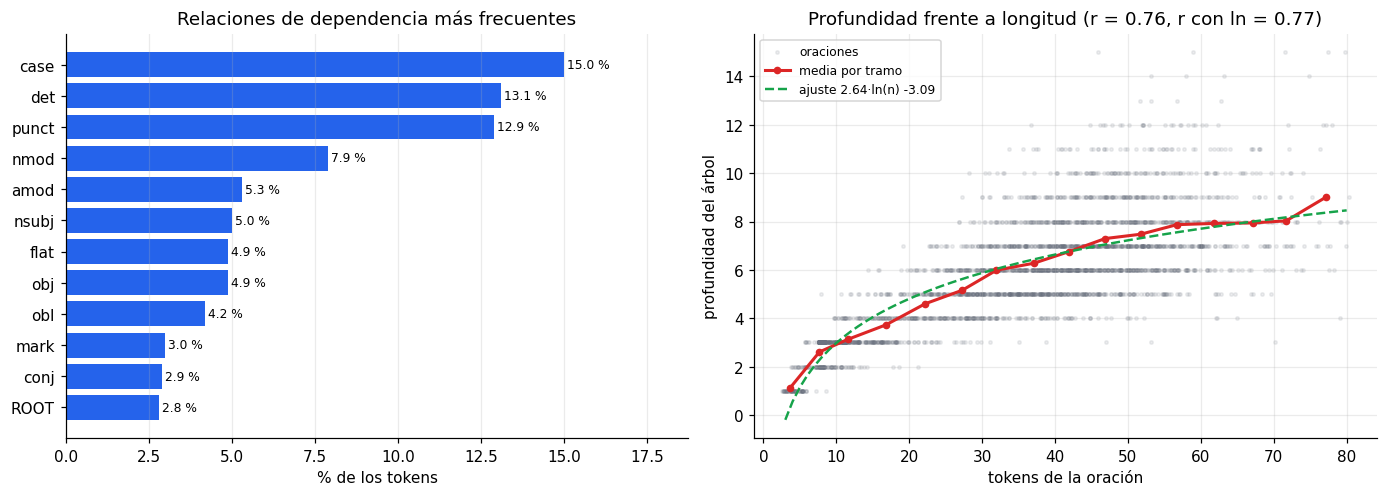

In [16]:
fig, ejes = plt.subplots(1, 2, figsize=(12.5, 4.4), layout="constrained")
top = tabla_rel.head(12).iloc[::-1]
barras = ejes[0].barh(top.relación, top["% de tokens"], color=AZUL)
ejes[0].bar_label(barras, labels=[f"{v:.1f} %" for v in top["% de tokens"]], fontsize=8, padding=2)
ejes[0].set(title="Relaciones de dependencia más frecuentes", xlabel="% de los tokens",
            xlim=(0, top["% de tokens"].max() * 1.25))
ejes[0].grid(axis="y", visible=False)

# Profundidad media por longitud: se agrupa para que la tendencia sea legible
grupos = pd.DataFrame({"longitud": longitudes, "profundidad": profundidades})
media = grupos.groupby(pd.cut(grupos.longitud, bins=range(0, 85, 5), right=False)).agg(
    x=("longitud", "mean"), y=("profundidad", "mean"), n=("profundidad", "size")).dropna()
ejes[1].scatter(longitudes + np.random.uniform(-0.4, 0.4, len(longitudes)), profundidades,
                s=5, alpha=0.12, color=GRIS, label="oraciones")
ejes[1].plot(media.x, media.y, color=ROJO, lw=2, marker="o", ms=4, label="media por tramo")
rejilla = np.arange(3, 81)
ejes[1].plot(rejilla, a_log * np.log(rejilla) + b_log, color=VERDE, ls="--", lw=1.6,
             label=f"ajuste {a_log:.2f}·ln(n) {b_log:+.2f}")
ejes[1].set(title=f"Profundidad frente a longitud (r = {correlacion:.2f}, r con ln = {correlacion_log:.2f})",
            xlabel="tokens de la oración", ylabel="profundidad del árbol")
ejes[1].legend(fontsize=8)
guardar_figura("fig03_05_parsing_estructura")

**Análisis.** El reparto de relaciones retrata el género. `case` y `det` encabezan la lista —juntas, casi el 28 % de
los tokens— porque el español periodístico está saturado de sintagmas preposicionales con artículo (*del Gobierno*,
*en la reunión*). `nmod` y `amod` ocupan el siguiente escalón porque los nombres se modifican de forma masiva: el
estilo de agencia acumula complementos del nombre en lugar de subordinadas. Y llama la atención que `flat` aparezca al
nivel de `nsubj` y `obj`: es la relación que UD usa para los nombres propios de varias palabras (*Real Madrid*,
*José María Aznar*), y su frecuencia confirma la densidad de entidades del corpus —una de cada veinte palabras es la
continuación de un nombre propio.

`nsubj`, `obj` y `obl` aparecen en cantidades parecidas, y la cifra de sujetos es reveladora al compararla con la de
verbos: hay unos 5.300 `nsubj` para casi 7.800 verbos plenos, de modo que **alrededor de un tercio de los verbos no
tiene sujeto explícito**. Es la elipsis del sujeto del español, que la morfología verbal permite; cualquier
extracción de información basada en `nsubj` heredará ese límite.

La profundidad crece con la longitud, pero **de forma claramente sublineal**. La correlación con el logaritmo de la
longitud es algo mayor que con la longitud misma, y el ajuste por mínimos cuadrados da un crecimiento de unos dos
niveles por cada duplicación de la longitud: una oración de 10 tokens tiene un árbol de unos 3 niveles y una de 80, de
unos 8, cuando una estructura encajada daría 79. Las oraciones largas de este corpus no son subordinaciones anidadas,
sino **coordinaciones, aposiciones y enumeraciones**, que añaden hermanos al mismo nivel (`conj`, `appos`) en lugar de
niveles nuevos. Es una propiedad útil en la práctica: el coste de recorrer el árbol para extraer relaciones no se
dispara con la longitud de la oración.

### 3.3 Extracción de tripletas sujeto–verbo–objeto

La utilidad práctica del análisis de dependencias es que convierte texto en estructura consultable. El caso canónico
es la extracción de tripletas **sujeto–verbo–objeto**: se recorren los verbos y se recogen sus hijos `nsubj` y `obj`.
Se exige que el sujeto y el objeto sean nombres o nombres propios (para descartar las tripletas cuyo sujeto es un
relativo *que*, que no identifican a nadie) y se lematiza para agrupar variantes.

In [17]:
def tripletas_svo(doc):
    """Tripletas (sujeto, verbo, objeto) con sujeto y objeto nominales."""
    salida = []
    for token in doc:
        if token.pos_ != "VERB":
            continue
        sujetos = [h for h in token.children if h.dep_ == "nsubj" and h.pos_ in ("NOUN", "PROPN")]
        objetos = [h for h in token.children if h.dep_ == "obj" and h.pos_ in ("NOUN", "PROPN")]
        if sujetos and objetos:
            salida.append((sujetos[0], token, objetos[0]))
    return salida

svo = Counter(); verbo_objeto = Counter(); pasivas = 0; total_verbos = 0
ejemplos_svo = []
for doc in docs_spacy:
    total_verbos += sum(1 for t in doc if t.pos_ == "VERB")
    pasivas += sum(1 for t in doc if t.dep_ in ("nsubj:pass", "aux:pass"))
    for s, v, o in tripletas_svo(doc):
        svo[(s.lemma_.lower(), v.lemma_.lower(), o.lemma_.lower())] += 1
        if len(ejemplos_svo) < 12:
            ejemplos_svo.append((s.text, v.text, o.text, doc.text[:78] + "…"))
    for t in doc:
        if t.pos_ == "VERB":
            for h in t.children:
                if h.dep_ == "obj" and h.pos_ in ("NOUN", "PROPN"):
                    verbo_objeto[(t.lemma_.lower(), h.lemma_.lower())] += 1

verbos_svo = Counter()
for (s, v, o), n in svo.items():
    verbos_svo[v] += n
METRICAS["parsing"].update({
    "tripletas_svo": int(sum(svo.values())), "tripletas_distintas": len(svo),
    "pares_verbo_objeto": int(sum(verbo_objeto.values())),
    "verbos_analizados": int(total_verbos),
    "cobertura_svo": round(sum(svo.values()) / total_verbos, 4),
    "top_verbos_svo": {v: int(n) for v, n in verbos_svo.most_common(8)},
})
print(f"Verbos plenos: {total_verbos:,} | tripletas SVO completas: {sum(svo.values()):,} "
      f"({sum(svo.values()) / total_verbos:.1%} de los verbos) | distintas: {len(svo):,}")
print(f"Marcas de pasiva (nsubj:pass / aux:pass): {pasivas:,}")

display(pd.DataFrame(verbo_objeto.most_common(12), columns=["(verbo, objeto)", "frecuencia"]))
display(pd.DataFrame(ejemplos_svo[:8], columns=["sujeto", "verbo", "objeto", "oración"]))
display(pd.DataFrame(verbos_svo.most_common(10), columns=["verbo", "tripletas"]))

Verbos plenos: 7,768 | tripletas SVO completas: 1,236 (15.9% de los verbos) | distintas: 1,184
Marcas de pasiva (nsubj:pass / aux:pass): 0


,"(verbo, objeto)",frecuencia
0,"(hacer, año)",14
1,"(ascender, millón)",9
2,"(hacer, semana)",8
3,"(hacer, mes)",6
4,"(cumplir, plazo)",6
5,"(tener, carácter)",6
6,"(plantear, necesidad)",5
7,"(destinar, millón)",5
8,"(cumplir, año)",5
9,"(pedir, año)",4


,sujeto,verbo,objeto,oración
0,Pirineos,transportados,Estadio,Unos 150 aviones suplementarios cruzarán entre esta noche y mañana los Pirineo…
1,agente,notificó,Hoover,Un agente de San Juan notificó el 21 de diciembre de 1961 a Hoover que el dire…
2,jefe,tiene,cualificación,"El jefe del citado servicio "" tiene la cualificación , capacidad de decisión y…"
3,departamento,tiene,competencias,"La delegada en Cádiz de la Consejería de Asuntos Sociales , Prudencia Rebollo …"
4,ciudadano,extraditado,Turquía,"El abogado destacó que existe un precedente reciente en el hecho de que "" un c…"
5,visitante,coger,ejemplar,"En una de ellas , la más dramática , el visitante puede coger un ejemplar de l…"
6,operarios,encontrado,bomba,Unos operarios que trabajaban en las obras de construcción de un aparcamiento …
7,gasolineras,mantienen,precio,"Las nueve gasolineras de Eroski , repartidas por Navarra , País Vasco y Murcia…"


,verbo,tripletas
0,tener,73
1,presentar,22
2,dar,21
3,pedir,20
4,hacer,18
5,mantener,15
6,destacar,14
7,ofrecer,13
8,realizar,13
9,recibir,12


**Análisis.** Las tripletas completas se extraen de una minoría de los verbos —alrededor del 16 %— y la razón es
estructural, no un fallo del analizador: la mayoría de los verbos del corpus **no tienen a la vez sujeto y objeto
nominales explícitos**.
Faltan sujetos por la elipsis del español, faltan objetos porque muchos verbos son intransitivos o van con
complemento preposicional (*informó de*, *se refirió a*), y en el estilo periodístico abundan las construcciones con
subordinada como objeto (*«dijo que…»*), donde el objeto es una oración entera y no un nombre.

Las tripletas individuales apenas se repiten —casi tantas distintas como totales—, lo que era previsible: cada
noticia habla de hechos particulares. La señal aparece al agregar. Los **pares verbo-objeto** sí muestran patrones
estables y describen el género con precisión: expresiones temporales tratadas como objeto (*hacer año*, *hacer
semana*), cifras (*ascender millón*, *destinar millón*) y el vocabulario administrativo (*cumplir plazo*, *presentar
conclusión*, *recibir premio*). Y los **verbos** que más tripletas producen son los verbos ligeros del discurso
institucional: *tener*, *presentar*, *dar*, *pedir*, *hacer*.

La lección metodológica es que las dependencias no dan «los hechos» de un texto de forma directa: dan un andamio
sobre el que hay que construir reglas conscientes de la lengua —aceptar complementos preposicionales, resolver la
elipsis de sujeto, tratar las subordinadas como argumento— si se quiere una extracción con cobertura razonable.

### 3.4 Ambigüedad de adjunción del sintagma preposicional

La ambigüedad de adjunción es el problema clásico del análisis sintáctico: en *«vio al hombre con el telescopio»* el
sintagma *con el telescopio* puede depender del verbo (*vio usando el telescopio*) o del nombre (*el hombre que
llevaba el telescopio*). Las dos estructuras son gramaticales y solo el conocimiento del mundo las separa. Un
analizador estadístico decide por la evidencia de su corpus de entrenamiento, sin representar ese conocimiento.

Se construyen pares mínimos —oraciones idénticas salvo el contenido del sintagma preposicional— para observar qué
decide el modelo y si la decisión cambia cuando debería cambiar.

In [18]:
# Cada prueba declara, para el sintagma que interesa, de qué palabra debería depender.
# `None` marca las oraciones genuinamente ambiguas, donde no hay respuesta correcta sin contexto.
pruebas = [
    ("La policía detuvo al sospechoso con una orden judicial.",
     {"orden": ("detuvo", "instrumento: depende del verbo")}),
    ("La policía detuvo al sospechoso con antecedentes penales.",
     {"antecedentes": ("sospechoso", "modificador: depende del nombre")}),
    ("El ministro anunció la reforma en el Congreso.",
     {"Congreso": ("anunció", "lugar del anuncio: depende del verbo")}),
    ("El ministro anunció la reforma del sistema de pensiones en el Congreso.",
     {"Congreso": ("anunció", "mismo lugar, con dos sintagmas nominales por delante")}),
    ("Vio al hombre con el telescopio.",
     {"telescopio": (None, "ambigua de verdad: sin contexto no hay respuesta correcta")}),
]
filas = []
for texto, esperadas in pruebas:
    doc = nlp(texto)
    for nucleo in doc:
        if nucleo.text not in esperadas:
            continue
        esperada, comentario = esperadas[nucleo.text]
        preposicion = next((h.text for h in nucleo.children if h.dep_ == "case"), "—")
        acierta = "—" if esperada is None else ("sí" if nucleo.head.text == esperada else "NO")
        filas.append({
            "oración": texto, "sintagma": f"{preposicion} … {nucleo.text}",
            "se adjunta a": nucleo.head.text, "relación": nucleo.dep_,
            "cabeza correcta": esperada or "ambigua", "¿acierta?": acierta, "lectura": comentario,
        })
tabla_sp = pd.DataFrame(filas)
METRICAS["parsing"]["ambiguedad_sp"] = tabla_sp[
    ["oración", "sintagma", "se adjunta a", "relación", "¿acierta?"]].to_dict("records")
display(tabla_sp[["oración", "sintagma", "se adjunta a", "relación", "cabeza correcta", "¿acierta?"]])

print("Par mínimo (mismas categorías gramaticales, distinto contenido del sintagma):")
for texto, _ in pruebas[:2]:
    doc = nlp(texto)
    print(" ", texto)
    print("   ", " | ".join(f"{t.text}←{t.head.text}({t.dep_})" for t in doc if t.dep_ != "punct"))
print("\nEfecto de la distancia (misma pregunta, oración corta y oración larga):")
for texto, _ in pruebas[2:4]:
    doc = nlp(texto)
    congreso = next(t for t in doc if t.text == "Congreso")
    print(f"  «{texto}»\n    → Congreso depende de «{congreso.head.text}» ({congreso.dep_})")

,oración,sintagma,se adjunta a,relación,cabeza correcta,¿acierta?
0,La policía detuvo al sospechoso con una orden judicial.,con … orden,detuvo,obl,detuvo,sí
1,La policía detuvo al sospechoso con antecedentes penales.,con … antecedentes,detuvo,obl,sospechoso,NO
2,El ministro anunció la reforma en el Congreso.,en … Congreso,anunció,obl,anunció,sí
3,El ministro anunció la reforma del sistema de pensiones en el Congreso.,en … Congreso,reforma,nmod,anunció,NO
4,Vio al hombre con el telescopio.,con … telescopio,Vio,obl,ambigua,—


Par mínimo (mismas categorías gramaticales, distinto contenido del sintagma):
  La policía detuvo al sospechoso con una orden judicial.
    La←policía(det) | policía←detuvo(nsubj) | detuvo←detuvo(ROOT) | al←sospechoso(case) | sospechoso←detuvo(obj) | con←orden(case) | una←orden(det) | orden←detuvo(obl) | judicial←orden(amod)
  La policía detuvo al sospechoso con antecedentes penales.
    La←policía(det) | policía←detuvo(nsubj) | detuvo←detuvo(ROOT) | al←sospechoso(case) | sospechoso←detuvo(obj) | con←antecedentes(case) | antecedentes←detuvo(obl) | penales←antecedentes(amod)

Efecto de la distancia (misma pregunta, oración corta y oración larga):
  «El ministro anunció la reforma en el Congreso.»
    → Congreso depende de «anunció» (obl)
  «El ministro anunció la reforma del sistema de pensiones en el Congreso.»
    → Congreso depende de «reforma» (nmod)


**Análisis.** El comportamiento del analizador es exactamente el que predice la teoría: **la relación `obl`
—adjunción al verbo— es su opción por defecto para el sintagma con *con***, y la mantiene en los dos miembros del par
mínimo. Acierta en *«detuvo al sospechoso con una orden judicial»*, donde el sintagma es instrumental y depende del
verbo, y **falla** en *«detuvo al sospechoso con antecedentes penales»*, donde *antecedentes penales* modifica al
sospechoso y debería ser `nmod` de *sospechoso*. Las dos oraciones son idénticas en categorías gramaticales; lo único
que las distingue es que una orden judicial es algo con lo que se detiene y unos antecedentes penales son algo que
alguien tiene. El modelo no dispone de esa información, así que aplica la preferencia aprendida.

El caso del *Congreso* aísla un segundo factor: **la distancia**. En la oración corta
*«anunció la reforma en el Congreso»* el analizador adjunta correctamente *Congreso* al verbo; al insertar entre
medias dos complementos del nombre —*«anunció la reforma del sistema de pensiones en el Congreso»*— cambia de
decisión y lo cuelga de un nombre, atraído por la cadena nominal previa. Las mismas palabras relevantes, la misma
relación correcta, y la respuesta cambia según lo que haya en medio.

Consecuencias prácticas. Primera: cualquier extracción de información que dependa de la adjunción de sintagmas
preposicionales (lugares, fechas, instrumentos) debe tratar `obl` y `nmod` como **candidatos** y no como verdad, y
validarlos con reglas o con el tipo semántico de la entidad. Segunda: el error es silencioso —el árbol es válido y no
hay señal de baja confianza—, de modo que solo una evaluación contra referencia lo detecta. Este corpus no trae
anotación de dependencias, lo que impone un límite a esta sección: la sintaxis se puede describir y sondear con pares
mínimos, pero no puntuar con una métrica como lo hacen las secciones 2 y 4.

## 4. Reconocimiento de entidades nombradas (*NER*)

### 4.1 El esquema IOB y la evaluación por entidad completa

CoNLL-2002 anota las entidades con el esquema **IOB**: `B-TIPO` marca el primer token de una entidad, `I-TIPO` los
siguientes y `O` los tokens que no pertenecen a ninguna. Son cuatro tipos: **PER** (personas), **ORG**
(organizaciones), **LOC** (lugares) y **MISC** (el resto de nombres propios: obras, leyes, acontecimientos,
nacionalidades, equipos con nombre no institucional).

Evaluar por token sería engañoso por dos motivos: la clase `O` domina la distribución, y acertar tres de los cuatro
tokens de *Ministerio de Asuntos Exteriores* no es medio acierto, es un fallo —quien consuma la salida obtendrá una
entidad distinta. El criterio de la tarea compartida, y el que se aplica aquí, es la **coincidencia exacta de tramo y
de tipo**: una entidad cuenta como acierto si y solo si coinciden la primera palabra, la última y el tipo.

El emparejamiento se implementa en `pln_lab.etiquetado` (`tramos_iob`, `contar_entidades`, `prf`) sin recurrir a
librerías externas de evaluación de secuencias, para que el criterio quede explícito y auditable.

In [19]:
# Verificación de la extracción de tramos sobre una oración anotada (breve, para poder leerla entera)
oracion_demo = next(
    (o for o in muestra if " ".join(w for w, _, _ in o).startswith("La Comisión Ejecutiva del Consorcio")),
    next(o for o in muestra if len(o) <= 20 and sum(1 for _, _, i in o if i.startswith("B-")) >= 3))
etiquetas_demo = [i for _, _, i in oracion_demo]
palabras_demo = [w for w, _, _ in oracion_demo]
print(" ".join(palabras_demo), "\n")
display(pd.DataFrame({"palabra": palabras_demo, "IOB": etiquetas_demo}).T)
print("Tramos extraídos:",
      [(t, " ".join(palabras_demo[a:b])) for t, a, b in tramos_iob(etiquetas_demo)])

# Casos límite del extractor
print("\nCasos límite:")
for caso in (["I-LOC", "I-LOC", "O"], ["B-PER", "I-ORG", "O"], ["O", "B-LOC"], ["B-LOC", "B-LOC"]):
    print(f"  {caso} -> {tramos_iob(caso)}")

La Comisión Ejecutiva del Consorcio Gran Teatro de Cáceres valorará la última edición del WOMAD . 



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
palabra,La,Comisión,Ejecutiva,del,Consorcio,Gran,Teatro,de,Cáceres,valorará,la,última,edición,del,WOMAD,.
IOB,O,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,O,O,O,O,O,B-MISC,O


Tramos extraídos: [('ORG', 'Comisión Ejecutiva del Consorcio Gran Teatro de Cáceres'), ('MISC', 'WOMAD')]

Casos límite:
  ['I-LOC', 'I-LOC', 'O'] -> [('LOC', 0, 2)]
  ['B-PER', 'I-ORG', 'O'] -> [('PER', 0, 1), ('ORG', 1, 2)]
  ['O', 'B-LOC'] -> [('LOC', 1, 2)]
  ['B-LOC', 'B-LOC'] -> [('LOC', 0, 1), ('LOC', 1, 2)]


In [20]:
# Tramos de referencia y predichos para toda la muestra
tramos_oro = [tramos_iob([i for _, _, i in o]) for o in muestra]
tramos_pred = [[(e.label_, e.start, e.end) for e in d.ents] for d in docs_spacy]
etiquetas_predichas = Counter(e.label_ for d in docs_spacy for e in d.ents)
print("Etiquetas que produce el modelo:", dict(etiquetas_predichas))

vp, fp, fn = contar_entidades(tramos_oro, tramos_pred)
filas = []
for tipo in TIPOS_ENTIDAD:
    p, r, f = prf(vp[tipo], fp[tipo], fn[tipo])
    filas.append({"tipo": tipo, "en el oro": vp[tipo] + fn[tipo], "predichas": vp[tipo] + fp[tipo],
                  "aciertos": vp[tipo], "precisión": p, "exhaustividad": r, "F1": f})
p, r, f = prf(sum(vp.values()), sum(fp.values()), sum(fn.values()))
filas.append({"tipo": "GLOBAL (micro)", "en el oro": sum(vp.values()) + sum(fn.values()),
              "predichas": sum(vp.values()) + sum(fp.values()), "aciertos": sum(vp.values()),
              "precisión": p, "exhaustividad": r, "F1": f})
tabla_ner = pd.DataFrame(filas).set_index("tipo")
macro_f1 = tabla_ner.loc[TIPOS_ENTIDAD, "F1"].mean()

# Criterio relajado: tramo correcto sin exigir el tipo
vpS = fpS = fnS = 0
for oro, pred in zip(tramos_oro, tramos_pred):
    a = {(x[1], x[2]) for x in oro}
    b = {(x[1], x[2]) for x in pred if x[0] in TIPOS_ENTIDAD}
    vpS += len(a & b); fpS += len(b - a); fnS += len(a - b)
pS, rS, fS = prf(vpS, fpS, fnS)

METRICAS["ner"] = {
    "entidades_oro": int(sum(vp.values()) + sum(fn.values())),
    "entidades_predichas": int(sum(vp.values()) + sum(fp.values())),
    "global": {"precision": round(p, 4), "exhaustividad": round(r, 4), "f1": round(f, 4)},
    "macro_f1": round(float(macro_f1), 4),
    "por_tipo": {t: {"precision": round(tabla_ner.loc[t, "precisión"], 4),
                     "exhaustividad": round(tabla_ner.loc[t, "exhaustividad"], 4),
                     "f1": round(tabla_ner.loc[t, "F1"], 4),
                     "oro": int(tabla_ner.loc[t, "en el oro"])} for t in TIPOS_ENTIDAD},
    "solo_tramo": {"precision": round(pS, 4), "exhaustividad": round(rS, 4), "f1": round(fS, 4)},
}
print(f"\nF1 macro (media de los cuatro tipos): {macro_f1:.3f}")
print(f"Criterio relajado (tramo correcto, tipo ignorado): P {pS:.3f} | R {rS:.3f} | F1 {fS:.3f}")
display(tabla_ner.style.format({"precisión": "{:.3f}", "exhaustividad": "{:.3f}", "F1": "{:.3f}"}))

Etiquetas que produce el modelo: {'LOC': 3165, 'PER': 1788, 'ORG': 2209, 'MISC': 752}

F1 macro (media de los cuatro tipos): 0.615
Criterio relajado (tramo correcto, tipo ignorado): P 0.835 | R 0.856 | F1 0.846


,en el oro,predichas,aciertos,precisión,exhaustividad,F1
tipo,,,,,,
PER,1780,1788,1489,0.833,0.837,0.835
ORG,3088,2209,1739,0.787,0.563,0.657
LOC,1973,3165,1610,0.509,0.816,0.627
MISC,875,752,279,0.371,0.319,0.343
GLOBAL (micro),7716,7914,5117,0.647,0.663,0.655


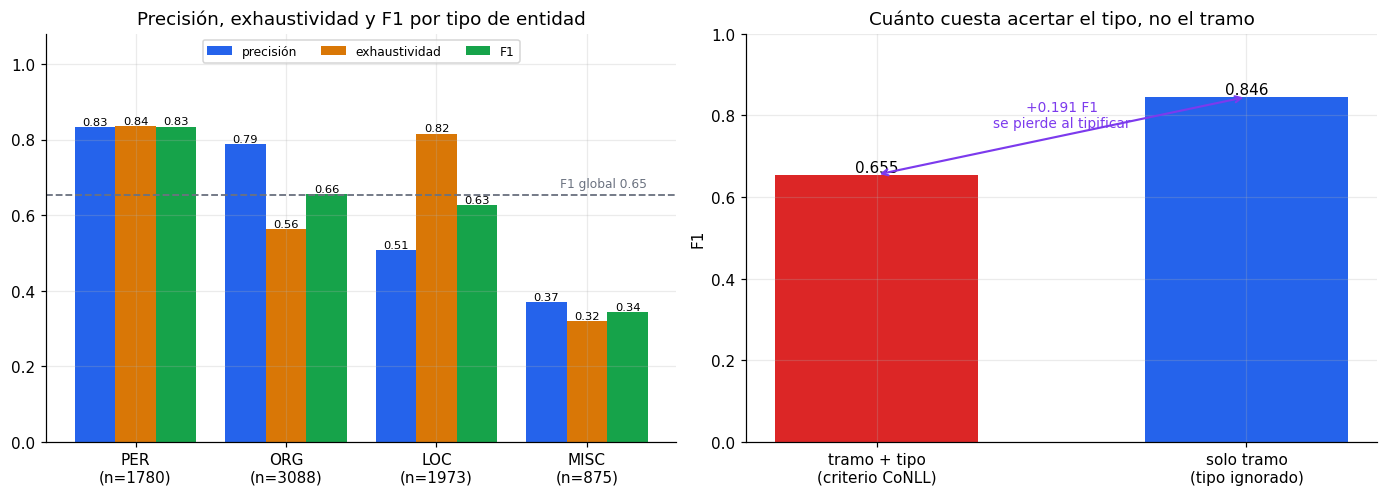

In [21]:
fig, ejes = plt.subplots(1, 2, figsize=(12.5, 4.4), layout="constrained")
x = np.arange(len(TIPOS_ENTIDAD)); ancho = 0.27
for k, (col, color) in enumerate(zip(["precisión", "exhaustividad", "F1"], [AZUL, NARANJA, VERDE])):
    b = ejes[0].bar(x + (k - 1) * ancho, tabla_ner.loc[TIPOS_ENTIDAD, col], ancho, color=color, label=col)
    ejes[0].bar_label(b, labels=[f"{v:.2f}" for v in tabla_ner.loc[TIPOS_ENTIDAD, col]], fontsize=7.5)
ejes[0].axhline(f, color=GRIS, ls="--", lw=1.2)
ejes[0].text(len(x) - 0.6, f + 0.02, f"F1 global {f:.2f}", color=GRIS, fontsize=8, ha="right")
ejes[0].set_xticks(x, [f"{t}\n(n={int(tabla_ner.loc[t, 'en el oro'])})" for t in TIPOS_ENTIDAD])
ejes[0].set(title="Precisión, exhaustividad y F1 por tipo de entidad", ylim=(0, 1.08))
ejes[0].legend(fontsize=8, ncol=3, loc="upper center")

comparativa = {"tramo + tipo\n(criterio CoNLL)": f, "solo tramo\n(tipo ignorado)": fS}
b = ejes[1].bar(list(comparativa), list(comparativa.values()), color=[ROJO, AZUL], width=0.55)
ejes[1].bar_label(b, labels=[f"{v:.3f}" for v in comparativa.values()], fontsize=10)
ejes[1].annotate("", xy=(1, fS), xytext=(0, f), arrowprops=dict(arrowstyle="<->", color=MORADO, lw=1.4))
ejes[1].text(0.5, (f + fS) / 2 + 0.02, f"+{fS - f:.3f} F1\nse pierde al tipificar",
             ha="center", color=MORADO, fontsize=9)
ejes[1].set(title="Cuánto cuesta acertar el tipo, no el tramo", ylabel="F1", ylim=(0, 1.0))
guardar_figura("fig03_06_ner_f1")

**Análisis.** El resultado global es una **F1 micro de 0,655** (precisión 0,647, exhaustividad 0,663) sobre 7.716
entidades de referencia, y una F1 macro de 0,615, más baja porque promedia a `MISC` con el mismo peso que a los tipos
grandes. Queda muy por debajo de las cifras que se publican para
este corpus con modelos entrenados sobre él (la tarea compartida de 2002 rondaba 0,80 y los sistemas actuales pasan de
0,87). La diferencia es esperable y no invalida el modelo: **spaCy no se entrenó con CoNLL-2002 y se evalúa aquí en
transferencia**, sobre un corpus de otra época y con una definición de los tipos que no es la suya.

El panel derecho aísla la causa principal. Cuando se exige solo que el **tramo** sea correcto, ignorando el tipo, la
F1 sube diecinueve puntos, de 0,655 a 0,846. Es decir: **el modelo localiza las entidades bastante bien y falla
sobre todo al clasificarlas.** Detectar dónde empieza y acaba un nombre propio es un problema de forma superficial
—mayúsculas, preposiciones internas, contexto sintáctico— que transfiere bien entre corpus; decidir si *Leeds* es un
lugar o un equipo de fútbol depende de una convención de anotación que cada corpus fija a su manera.

Por tipos, el patrón es nítido. **PER** es el mejor con diferencia (F1 0,835, con precisión y exhaustividad casi
idénticas): los nombres de persona tienen forma y contexto muy característicos (*el presidente X*, *X dijo*) y su
definición no admite discusión. **ORG** pierde exhaustividad (0,563 frente a una precisión de 0,787) y **LOC** pierde
precisión (0,509 frente a una exhaustividad de 0,816): son las dos caras de la misma moneda, porque el modelo predice
muchos `LOC` donde el corpus dice `ORG`; de hecho predice 3.165 lugares cuando el corpus solo anota 1.973. **MISC** es
el peor con mucha diferencia (F1 0,343) y se analiza aparte, porque no es un tipo en el sentido en que lo son los otros
tres, sino un cajón de sastre definido por exclusión.

### 4.2 Anatomía del error

Cada entidad del estándar de oro que el modelo no reprodujo exactamente se clasifica en tres categorías según lo que
el modelo predijo sobre esas mismas palabras: **tipo** (el tramo coincide, el tipo no), **frontera** (hay
solapamiento parcial) y **omisión** (no hay ninguna predicción). Se añaden las **espurias**: entidades predichas que
no solapan con ninguna del oro.

In [22]:
clases = Counter(); confusion_tipo = Counter(); errores_detalle = []
espurias = 0
for oracion, oro, pred in zip(muestra, tramos_oro, tramos_pred):
    palabras = [w for w, _, _ in oracion]
    pred_validas = [t for t in pred if t[0] in TIPOS_ENTIDAD]
    conjunto_oro = set(oro)
    for tramo in sorted(conjunto_oro - set(pred_validas)):
        clase, candidato = clasificar_error(tramo, pred_validas)
        clases[clase] += 1
        if clase == "tipo":
            confusion_tipo[(tramo[0], candidato[0])] += 1
        errores_detalle.append({
            "clase": clase, "oro": " ".join(palabras[tramo[1]:tramo[2]]), "tipo oro": tramo[0],
            "predicho": " ".join(palabras[candidato[1]:candidato[2]]) if candidato else "—",
            "tipo predicho": candidato[0] if candidato else "—",
            "contexto": " ".join(palabras[max(0, tramo[1] - 4):tramo[2] + 4]),
        })
    for tramo in pred_validas:
        if not any(t[1] < tramo[2] and t[2] > tramo[1] for t in conjunto_oro):
            espurias += 1
clases["espuria (falso positivo)"] = espurias
METRICAS["ner"]["clases_error"] = {k: int(v) for k, v in clases.items()}
METRICAS["ner"]["confusion_tipo"] = {f"{a}->{b}": int(n) for (a, b), n in confusion_tipo.most_common(8)}
print("Clases de error:", dict(clases.most_common()))

matriz_tipo = pd.DataFrame(0, index=TIPOS_ENTIDAD, columns=TIPOS_ENTIDAD)
for (a, b), n in confusion_tipo.items():
    if a in TIPOS_ENTIDAD and b in TIPOS_ENTIDAD:
        matriz_tipo.loc[a, b] = n
for t in TIPOS_ENTIDAD:
    matriz_tipo.loc[t, t] = vp[t]
display(matriz_tipo)

Clases de error: {'tipo': 1491, 'frontera': 841, 'espuria (falso positivo)': 517, 'omisión': 267}


,PER,ORG,LOC,MISC
PER,1489,19,133,38
ORG,101,1739,626,192
LOC,21,37,1610,22
MISC,53,136,113,279


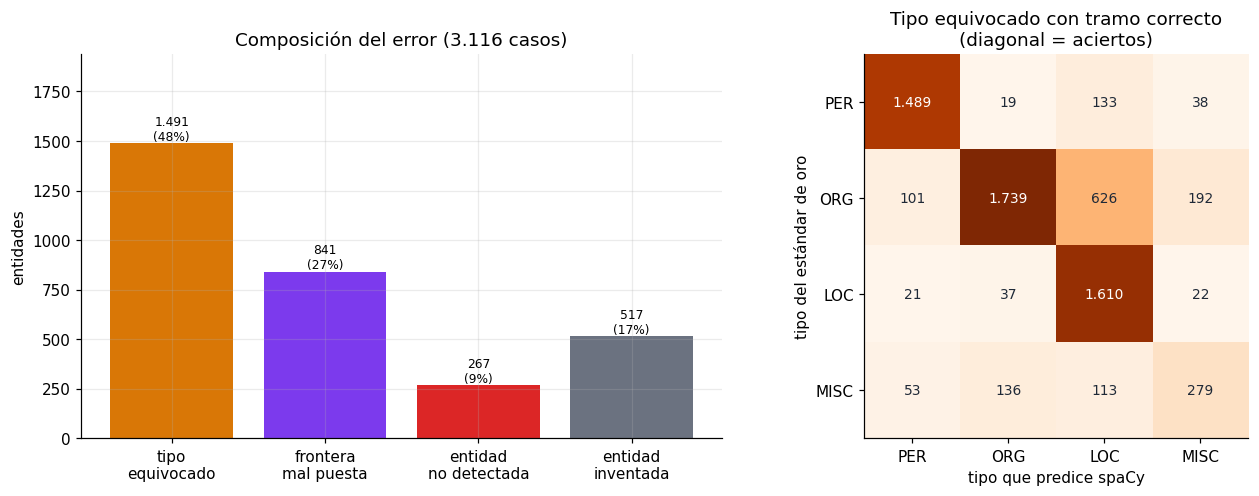

In [23]:
fig, ejes = plt.subplots(1, 2, figsize=(12.5, 4.4), layout="constrained")
orden_clases = ["tipo", "frontera", "omisión", "espuria (falso positivo)"]
vals = [clases[c] for c in orden_clases]
b = ejes[0].bar(["tipo\nequivocado", "frontera\nmal puesta", "entidad\nno detectada", "entidad\ninventada"],
                vals, color=[NARANJA, MORADO, ROJO, GRIS])
ejes[0].bar_label(b, labels=[f"{v:,}".replace(",", ".") + f"\n({v / sum(vals):.0%})" for v in vals], fontsize=8)
ejes[0].set(title=f"Composición del error ({sum(vals):,} casos)".replace(",", "."), ylabel="entidades",
            ylim=(0, max(vals) * 1.3))

imagen = ejes[1].imshow(matriz_tipo.values, cmap="Oranges")
ejes[1].set_xticks(range(4), TIPOS_ENTIDAD); ejes[1].set_yticks(range(4), TIPOS_ENTIDAD)
ejes[1].set(xlabel="tipo que predice spaCy", ylabel="tipo del estándar de oro",
            title="Tipo equivocado con tramo correcto\n(diagonal = aciertos)")
for i in range(4):
    for j in range(4):
        v = matriz_tipo.values[i, j]
        ejes[1].text(j, i, f"{v:,}".replace(",", "."), ha="center", va="center", fontsize=9,
                     color="white" if v > matriz_tipo.values.max() * 0.55 else "#1f2937")
ejes[1].grid(False)
guardar_figura("fig03_07_ner_errores")

**Análisis.** La composición del error confirma el diagnóstico de la sección anterior y lo cuantifica. De los 2.599
falsos negativos, el **tipo equivocado con tramo correcto** son 1.491 (57 %), las **fronteras mal puestas** 841
(32 %) y las **omisiones** —entidades sobre las que el modelo no predijo nada— solo 267 (10 %), a las que se añaden
517 entidades **espurias**. Un reconocedor que no viera las entidades produciría el perfil opuesto. Este produce casi
siempre *algo* sobre las palabras correctas y se equivoca al etiquetarlo.

La matriz de tipos identifica la confusión dominante: **ORG anotado como LOC, 626 casos**, cuatro veces más que la
siguiente. El mecanismo es la **metonimia
institucional**, omnipresente en el lenguaje periodístico: *Belgrado* retira sus tropas, *Leeds* tiene hinchas,
*El Segre* es un centro de menores. El corpus de CoNLL-2002 aplica el criterio funcional —si el nombre de lugar actúa
como organización se anota `ORG`—, mientras que spaCy, entrenado con otros datos, se guía por la forma del nombre y
devuelve `LOC`. No es un error de detección sino un **desacuerdo de criterio de anotación**, el mismo fenómeno que en
la sección 2 inflaba el desacuerdo de POS. Aparece también en `PER`→`LOC` (133 casos), que afecta a los nombres de
persona que coinciden con topónimos o que el modelo no reconoce como personas (*Odón Elorza*, *San Juan*), y en las dos
direcciones entre `MISC` y `ORG`.

Los errores de **frontera** tienen dos causas visibles en los ejemplos de la sección siguiente: el modelo **absorbe
modificadores** que el corpus deja fuera (*Guerra Civil* → *Guerra Civil española*) y **fusiona entidades contiguas**
cuando entre ellas hay preposiciones o artículos (*Cádiz* + *Consejería de Asuntos Sociales* → un solo tramo). Lo
segundo es más grave: destruye dos entidades a la vez, cuenta como dos falsos negativos y un falso positivo, y produce
un tramo que no corresponde a nada.

### 4.3 Quince errores reales

In [24]:
# Selección equilibrada: casos de cada clase, priorizando los más ilustrativos
detalle = pd.DataFrame(errores_detalle)
muestra_errores = pd.concat([
    detalle[(detalle.clase == "tipo") & (detalle["tipo oro"] == "ORG") & (detalle["tipo predicho"] == "LOC")].head(4),
    detalle[(detalle.clase == "tipo") & (detalle["tipo oro"] == "PER")].head(2),
    detalle[(detalle.clase == "tipo") & (detalle["tipo oro"] == "MISC")].head(2),
    detalle[detalle.clase == "frontera"].head(5),
    detalle[detalle.clase == "omisión"].head(2),
]).reset_index(drop=True)
muestra_errores.index = range(1, len(muestra_errores) + 1)
METRICAS["ner"]["ejemplos_error"] = muestra_errores.to_dict("records")
display(muestra_errores[["clase", "oro", "tipo oro", "predicho", "tipo predicho", "contexto"]])

,clase,oro,tipo oro,predicho,tipo predicho,contexto
1,tipo,Parlamento Vasco,ORG,Parlamento Vasco,LOC,"por Ley en el Parlamento Vasco "" ."
2,tipo,El Segre,ORG,El Segre,LOC,"el centro de menores El Segre "" no es un"
3,tipo,Leeds,ORG,Leeds,LOC,los dos hinchas del Leeds inglés que fallecieron apuñalados
4,tipo,Belgrado,ORG,Belgrado,LOC,1999 y obligó a Belgrado a retirar sus tropas
5,tipo,Odón Elorza,PER,Odón Elorza,LOC,"ofreció junto al alcalde Odón Elorza , que esta medida"
6,tipo,Marcos,PER,Marcos,MISC,"excesivo "" , según Marcos , al que le"
7,tipo,Pirineos,MISC,Pirineos,LOC,noche y mañana los Pirineos y sus pasajeros serán
8,tipo,Agricultura. Pesca,MISC,Agricultura. Pesca,PER,"el ministro marroquí de Agricultura. Pesca , y espero que"
9,frontera,Cádiz,LOC,Cádiz de la Consejería de Asuntos Sociales,LOC,La delegada en Cádiz de la Consejería de
10,frontera,Consejería de Asuntos Sociales,ORG,Cádiz de la Consejería de Asuntos Sociales,LOC,"en Cádiz de la Consejería de Asuntos Sociales , Prudencia Rebollo ,"


**Análisis.** La tabla permite juzgar caso por caso, y el juicio no favorece siempre al estándar de oro:

* **Metonimia (`ORG` → `LOC`).** *Parlamento Vasco*, *Leeds* («los hinchas del Leeds inglés»), *El Segre* («el centro
  de menores El Segre»), *Belgrado* («obligó a Belgrado a retirar sus tropas»): el corpus anota la función, spaCy la
  forma. Para una aplicación de extracción de información la etiqueta de spaCy es a veces incluso más útil, porque
  conserva el lugar; para reproducir el corpus, es un error.
* **Personas tomadas por otra cosa.** *Odón Elorza* etiquetado `LOC` pese al contexto *«junto al alcalde Odón
  Elorza»* —el apellido tiene forma de topónimo vasco— y *Marcos* etiquetado `MISC`. Estos sí son errores del modelo, y
  son los que explican que la precisión de `LOC` baje a 0,509.
* **Frontera por modificador.** *Guerra Civil* frente a *Guerra Civil española*: el adjetivo gentilicio va dentro de
  la entidad para el modelo y fuera para el anotador. Es una convención que habría que fijar antes de evaluar, no una
  equivocación.
* **Fusión de entidades.** *Cádiz* y *Consejería de Asuntos Sociales* unidas en un solo tramo; *estadio del Milenio* y
  *Cardiff* unidas en *Milenio de Cardiff*. Aquí sí hay un error claro, y es el más costoso de todos.
* **Artefactos de la anotación original.** *«Agricultura. Pesca»*, resto de un nombre de ministerio que la
  tokenización de 2002 partió, anotado `MISC` y leído por el modelo como nombre de persona.
* **Omisiones.** Son pocas y suelen ser nombres aislados sin contexto que los desambigüe (*Bilbao* en una enumeración,
  *Justicia* sin determinante).

El patrón general es que **una parte sustancial de lo que la métrica cuenta como error es desacuerdo de convención**.
La consecuencia práctica no es relativizar la evaluación, sino la inversa: si se quiere un reconocedor que respete
unas convenciones concretas, hay que **ajustarlo con datos anotados según esas convenciones**; ninguna elección de
modelo pre-entrenado sustituye ese paso.

### 4.4 El efecto de la antigüedad del corpus

El corpus es de mayo de 2000. El modelo `es_core_news_md` se entrenó con textos muy posteriores. Esa distancia de un
cuarto de siglo afecta al reconocimiento de tres maneras que se pueden medir o ilustrar: entidades que ya no existen
o han cambiado de nombre, entidades cuya frecuencia ha caído, y convenciones tipográficas de la época (siglas,
abreviaturas y marcas de agencia).

In [25]:
# ¿La exhaustividad depende de la longitud de la entidad y de su frecuencia en el corpus?
frecuencia_oro = Counter()
for oracion, oro in zip(muestra, tramos_oro):
    palabras = [w for w, _, _ in oracion]
    for t, a, b in oro:
        frecuencia_oro[" ".join(palabras[a:b]).lower()] += 1

filas = []
for oracion, oro, pred in zip(muestra, tramos_oro, tramos_pred):
    palabras = [w for w, _, _ in oracion]
    conjunto_pred = {t for t in pred if t[0] in TIPOS_ENTIDAD}
    for t, a, b in oro:
        texto_ent = " ".join(palabras[a:b])
        filas.append({"texto": texto_ent, "tipo": t, "longitud": b - a,
                      "frecuencia": frecuencia_oro[texto_ent.lower()],
                      "acierto": (t, a, b) in conjunto_pred,
                      "detectada": any(q[1] < b and q[2] > a for q in conjunto_pred)})
entidades = pd.DataFrame(filas)

por_longitud = entidades.assign(
    tramo=pd.cut(entidades.longitud, [0, 1, 2, 3, 100], labels=["1 token", "2", "3", "4 o más"])
).groupby("tramo", observed=True).agg(entidades=("acierto", "size"),
                                      exhaustividad=("acierto", "mean"),
                                      detección=("detectada", "mean"))
por_frecuencia = entidades.assign(
    grupo=pd.cut(entidades.frecuencia, [0, 1, 3, 10, 10_000],
                 labels=["1 vez", "2–3", "4–10", "más de 10"])
).groupby("grupo", observed=True).agg(entidades=("acierto", "size"),
                                     exhaustividad=("acierto", "mean"),
                                     detección=("detectada", "mean"))
METRICAS["ner"]["por_longitud"] = por_longitud.round(4).to_dict()
METRICAS["ner"]["por_frecuencia"] = por_frecuencia.round(4).to_dict()
display(por_longitud.style.format({"exhaustividad": "{:.3f}", "detección": "{:.3f}"}))
display(por_frecuencia.style.format({"exhaustividad": "{:.3f}", "detección": "{:.3f}"}))

# Entidades de época: siglas y nombres de 2000 que el modelo no reproduce
fallidas = entidades[~entidades.acierto].texto.value_counts()
siglas = [t for t in fallidas.index if t.isupper() and 2 <= len(t) <= 8][:14]
print("\nSiglas y abreviaturas de la época que el modelo no reproduce exactamente:")
print(" · ".join(siglas))
print("\nEntidades más veces falladas:", " · ".join(f"{t} ({n})" for t, n in fallidas.head(10).items()))

,entidades,exhaustividad,detección
tramo,,,
1 token,4646,0.658,0.956
2,1668,0.751,0.984
3,717,0.667,0.979
4 o más,685,0.485,0.969


,entidades,exhaustividad,detección
grupo,,,
1 vez,2951,0.627,0.964
2–3,1615,0.645,0.953
4–10,1283,0.661,0.952
más de 10,1867,0.738,0.987



Siglas y abreviaturas de la época que el modelo no reproduce exactamente:
EFECOM · EFE · EEUU · ITA · PIB · ACNO · CPLRE · CAN · IPC · GOBIERNO · VIH · ISR · ONG · BUL

Entidades más veces falladas: Gobierno (84) · Valencia (28) · Estado (24) · Estados Unidos (19) · Ejército (18) · China (16) · Administración (15) · Ayuntamiento (14) · Barcelona (12) · Israel (12)


**Análisis.** El dato más importante de la primera tabla es la columna de **detección**: el modelo predice *alguna*
entidad sobre el 95-98 % de las palabras que el corpus marca como entidad, **y lo hace por igual sea la entidad de un
token o de cinco**. Localizar no le cuesta. Toda la variación está en la columna de *exhaustividad*, que exige tramo y
tipo exactos, y ahí la brecha respecto a la detección se abre de 30 puntos en las entidades de un token a **48 puntos
en las de cuatro o más**: los nombres largos —*Consejería de Asuntos Sociales*, *Concurso Internacional para el
Monumento a la Independencia del Uruguay*— acumulan errores de frontera porque contienen preposiciones, artículos y
adjetivos cuya pertenencia a la entidad es discutible.

Conviene notar que la relación con la longitud **no es monótona**: las entidades de dos tokens son las que mejor se
aciertan (0,751), por encima de las de un solo token (0,658). La razón es que los dos errores dominantes afectan a
poblaciones distintas —las entidades de un token son las que sufren la metonimia (*Leeds*, *Belgrado*, *Gobierno*), y
las largas las que sufren la frontera—, mientras que un nombre de dos palabras suele ser un nombre de persona, el caso
más fácil. La **frecuencia**, en cambio, sí actúa de forma monótona: la exhaustividad sube del 0,627 en las entidades
que aparecen una sola vez al 0,738 en las que aparecen más de diez veces, que son las institucionales conocidas.

El efecto de la fecha se aprecia mejor en las listas concretas. Buena parte de lo que falla son **siglas y marcas de
época**: `EFECOM` (la marca con que la agencia cerraba sus despachos económicos, que hoy ningún modelo ha visto), los
códigos de país de tres letras de los resultados deportivos (`ESP`, `ITA`, `BUL`), acrónimos de organismos de 2000
(`ACNO`, `CPLRE`, `ISR`) y nombres de instituciones y cargos de entonces —reorganizaciones ministeriales, entidades
financieras fusionadas desde entonces, partidos y sindicatos con otra denominación— que no forman parte del
vocabulario de entidades que el modelo aprendió.

La lista de entidades **más veces falladas** apunta sin embargo a otra causa, y conviene no confundirlas: la encabeza
*Gobierno* con 84 fallos, seguida de *Valencia* (28), *Estado* (24) y *Ejército* (18). No son nombres olvidados, son
los casos de metonimia y de nombre común usado como institución, es decir el mismo desacuerdo de criterio de la
sección 4.2. El desplazamiento temporal explica la cola de la distribución —las entidades raras y de época—, no su
cabeza.

Es el fenómeno de **desplazamiento temporal** (*temporal drift*) del reconocimiento de entidades, y es el argumento
más fuerte a favor de reentrenar o ajustar el reconocedor con datos del dominio y del periodo en que se va a
aplicar: no basta con elegir un modelo mejor, porque el conocimiento que falta es conocimiento del mundo de un
momento concreto. En sentido inverso, también conviene desconfiar de evaluar un modelo actual sobre un corpus
antiguo: parte de la F1 perdida mide la distancia entre dos épocas, no la calidad del sistema.

## 5. Métricas del notebook

In [26]:
(DIR_RES / "metricas_03.json").write_text(
    json.dumps(METRICAS, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Guardado:", DIR_RES / "metricas_03.json")
print(json.dumps({
    "POS: exactitud estricta": METRICAS["pos"]["exactitud_global"],
    "POS: exactitud fuera de entidades": METRICAS["pos"]["exactitud_fuera_entidades"],
    "POS: exactitud con NOUN≡PROPN": METRICAS["pos"]["spacy_indultada"],
    "POS: línea base": METRICAS["pos"]["linea_base"]["exactitud"],
    "POS: línea base en palabras desconocidas": METRICAS["pos"]["linea_base"]["exactitud_desconocidas"],
    "Parsing: profundidad media": METRICAS["parsing"]["profundidad_media"],
    "NER: F1 global": METRICAS["ner"]["global"]["f1"],
    "NER: F1 solo tramo": METRICAS["ner"]["solo_tramo"]["f1"],
    "NER: F1 por tipo": {t: METRICAS["ner"]["por_tipo"][t]["f1"] for t in TIPOS_ENTIDAD},
}, ensure_ascii=False, indent=2))

Guardado: /home/claude/lab-procesamiento-texto/notebooks/resultados/metricas_03.json
{
  "POS: exactitud estricta": 0.8546,
  "POS: exactitud fuera de entidades": 0.9519,
  "POS: exactitud con NOUN≡PROPN": 0.927,
  "POS: línea base": 0.9239,
  "POS: línea base en palabras desconocidas": 0.3234,
  "Parsing: profundidad media": 5.85,
  "NER: F1 global": 0.6548,
  "NER: F1 solo tramo": 0.8456,
  "NER: F1 por tipo": {
    "PER": 0.8346,
    "ORG": 0.6566,
    "LOC": 0.6267,
    "MISC": 0.343
  }
}


## 6. Hallazgos del notebook

- **La exactitud estricta del etiquetado (85,5 % sobre 107.033 tokens) no mide lo que parece medir.** Fuera de las
  entidades nombradas spaCy alcanza el 95,2 %; dentro de ellas se hunde al 18,5 %, porque la capa morfosintáctica de
  CoNLL-2002 se generó automáticamente y etiqueta los nombres propios como nombres comunes o adjetivos (1.846 tokens
  `NP` frente a más de 27.000 tokens `NC` con mayúscula inicial). El 71 % de todos los desacuerdos se concentra en el
  13 % de tokens que forman parte de una entidad, e indultar la distinción `NOUN`/`PROPN` sube la exactitud al 92,7 %.
- **La línea base de la etiqueta más frecuente gana a spaCy con el criterio estricto (92,4 % frente a 85,5 %) y
  pierde con el criterio corregido** (94,0 % frente a 95,2 % fuera de entidades). No etiqueta mejor: reproduce mejor
  la convención del corpus con el que se entrenó. En el 4,5 % de tokens que nunca vio su exactitud se hunde al 32,3 %
  frente al 65,6 % de spaCy (79,2 % indultando `NOUN`/`PROPN`, porque el 27,8 % de esas palabras son parte de
  entidades). Una línea base que gana es motivo para revisar el criterio de evaluación antes que el sistema.
- **El mapeo EAGLES→UPOS cubre las 60 etiquetas del corpus** con 14 categorías universales y sin tokens huérfanos,
  pero tres diferencias de inventario generan desacuerdo estructural: los modales y la cópula *estar*, que EAGLES trata
  como verbos plenos y UD como `AUX` (579 tokens: *estar* 239, *poder* 203, *deber* 90); los participios `VMP`, que
  spaCy reparte entre `VERB` (705) y `ADJ` (238) según la función; y la frontera `DET`/`PRON` (325 tokens). Ninguna es
  un error del modelo.
- **La profundidad del árbol de dependencias crece de forma logarítmica con la longitud de la oración**, no lineal:
  unos dos niveles más por cada duplicación de la longitud, de modo que una oración de 80 tokens alcanza una
  profundidad de 8 cuando una estructura encajada daría 79. Las oraciones largas del corpus son coordinaciones,
  aposiciones y enumeraciones. Las relaciones dominantes (`case` y `det`, casi el 28 % de los tokens, más `nmod`,
  `amod` y `flat`) retratan un género de sintagmas preposicionales densos y nombres propios de varias palabras.
- **Las tripletas sujeto-verbo-objeto se extraen solo del 15,9 % de los verbos**, por la elipsis del sujeto en español
  —alrededor de un tercio de los verbos no tiene `nsubj` explícito— y por las subordinadas como objeto
  (*«dijo que…»*). Los pares verbo-objeto agregados sí revelan los patrones del género (*ascender millón*,
  *cumplir plazo*, *presentar conclusión*).
- **La ambigüedad de adjunción del sintagma preposicional se resuelve por preferencia aprendida, no por análisis.**
  En un par mínimo idéntico salvo el contenido del sintagma, el analizador adjunta al verbo (`obl`) en los dos casos:
  acierta en *«detuvo … con una orden judicial»* y falla en *«detuvo … con antecedentes penales»*. Y la decisión
  depende de la distancia: adjunta *en el Congreso* al verbo en la oración corta y a un nombre al intercalar dos
  complementos nominales. El error es silencioso: el árbol es válido y no hay señal de baja confianza.
- **El NER alcanza una F1 micro de 0,655 con coincidencia exacta de tramo y tipo, y de 0,846 si solo se exige el
  tramo** (F1 macro 0,615). spaCy localiza las entidades —predice algo sobre el 96 % de las entidades del oro— y falla
  al clasificarlas: de los 2.599 falsos negativos, 1.491 son de tipo, 841 de frontera y solo 267 omisiones.
- **La confusión dominante es `ORG` anotado como `LOC` (626 casos)** y su causa es la metonimia institucional
  (*Belgrado* retira tropas, *Leeds* tiene hinchas). El corpus anota la función, el modelo la forma. Por tipos, `PER`
  es el más fiable (F1 0,835) y `MISC` el menos (F1 0,343), porque `MISC` no es una clase semántica sino un cajón de
  sastre definido por exclusión en 2002.
- **El desplazamiento temporal es medible pero explica la cola, no la cabeza del error**: las entidades que aparecen
  una sola vez se aciertan peor (0,627) que las que aparecen más de diez veces (0,738), y entre las fallidas destacan
  las marcas de época (`EFECOM`, los códigos de país de los resultados deportivos, acrónimos como `ACNO` o `CPLRE`).
  Pero las entidades más veces falladas son *Gobierno* (84), *Valencia* (28) y *Estado* (24): metonimia, no olvido.
  Evaluar un modelo actual sobre un corpus de hace 25 años mide, en parte, la distancia entre dos épocas.
- **Consecuencia para el laboratorio:** un modelo pre-entrenado sirve para localizar estructura (tramos de entidad,
  árboles de dependencias), pero para respetar un esquema de etiquetas concreto hace falta ajuste con datos anotados
  según ese esquema. Y toda métrica contra un estándar de oro debe auditarse antes de interpretarse: aquí, dos de las
  tres cifras principales cambian de significado al inspeccionar cómo se anotó el corpus.

## Referencias

- Honnibal, M., Montani, I., Van Landeghem, S. y Boyd, A. (2020). *spaCy: Industrial-strength Natural Language
  Processing in Python*. Zenodo. https://doi.org/10.5281/zenodo.1212303
- Jurafsky, D. y Martin, J. H. (2025). *Speech and Language Processing* (3.ª ed., borrador).
  https://web.stanford.edu/~jurafsky/slp3/
- Leech, G. y Wilson, A. (1996). *EAGLES recommendations for the morphosyntactic annotation of corpora*. Expert
  Advisory Group on Language Engineering Standards.
- Nivre, J., de Marneffe, M.-C., Ginter, F., Hajič, J., Manning, C. D., Pyysalo, S., Schuster, S., Tyers, F. y
  Zeman, D. (2020). Universal Dependencies v2: An evergrowing multilingual treebank collection. En *Proceedings of
  the 12th Language Resources and Evaluation Conference* (pp. 4034–4043). European Language Resources Association.
- Tjong Kim Sang, E. F. (2002). Introduction to the CoNLL-2002 shared task: Language-independent named entity
  recognition. En *Proceedings of the 6th Conference on Natural Language Learning (CoNLL-2002)* (pp. 155–158).
  Association for Computational Linguistics. https://doi.org/10.3115/1118853.1118877